<a href="https://colab.research.google.com/github/alaaguedda/Hybrid-Texture-Intelligence/blob/main/texture_classification_efficientnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Texture Image Classification – Full Experimental Pipeline
## ML vs DL | No Aug → Classical Aug → GAN Aug

**GPU Runtime required** — Go to `Runtime > Change runtime type > T4 GPU`

---
### Stages:
1. Setup & Dataset Download
2. Preprocessing
3. **Stage 1** – Baseline (No Augmentation)
4. **Stage 2** – Classical Augmentation
5. **Stage 3** – GAN-Based Augmentation
6. Final Comparison & Analysis

##  0. Install Dependencies

In [1]:
%%capture
!pip install kaggle scikit-image seaborn torch torchvision scikit-learn matplotlib numpy pillow tqdm
!pip install albumentations

##  1. Kaggle API Setup & Dataset Download

In [2]:
# Upload your kaggle.json here, OR set credentials manually:
import os

# OPTION A: Upload kaggle.json
from google.colab import files
print('Upload your kaggle.json API token:')
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
print('Kaggle credentials set.')

Upload your kaggle.json API token:


Saving kaggle.json to kaggle.json
Kaggle credentials set.


In [3]:
# Download DTD dataset
!kaggle datasets download -d jmexpert/describable-textures-dataset-dtd -p data --unzip
print('Dataset downloaded.')

Dataset URL: https://www.kaggle.com/datasets/jmexpert/describable-textures-dataset-dtd
License(s): unknown
100% 1.17G/1.17G [00:14<00:00, 89.2MB/s]

Dataset downloaded.


## 🔍 2. Explore Dataset & Select 5 Classes

In [4]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Auto-detect dataset root
def find_dataset_root(base='data'):
    for root, dirs, files in os.walk(base):
        if len(dirs) > 5 and not any(d.startswith('.') for d in dirs):
            img_count = sum(1 for d in dirs if len(glob.glob(os.path.join(root, d, '*.jpg'))) > 0)
            if img_count > 3:
                return root
    return base

DATA_ROOT = find_dataset_root('data')
all_classes = sorted([d for d in os.listdir(DATA_ROOT)
                      if os.path.isdir(os.path.join(DATA_ROOT, d))])
print(f'Dataset root: {DATA_ROOT}')
print(f'Total classes found: {len(all_classes)}')
print(f'All classes: {all_classes}')

Dataset root: data/dtd-r1.0.1/dtd/images
Total classes found: 47
All classes: ['banded', 'blotchy', 'braided', 'bubbly', 'bumpy', 'chequered', 'cobwebbed', 'cracked', 'crosshatched', 'crystalline', 'dotted', 'fibrous', 'flecked', 'freckled', 'frilly', 'gauzy', 'grid', 'grooved', 'honeycombed', 'interlaced', 'knitted', 'lacelike', 'lined', 'marbled', 'matted', 'meshed', 'paisley', 'perforated', 'pitted', 'pleated', 'polka-dotted', 'porous', 'potholed', 'scaly', 'smeared', 'spiralled', 'sprinkled', 'stained', 'stratified', 'striped', 'studded', 'swirly', 'veined', 'waffled', 'woven', 'wrinkled', 'zigzagged']


In [5]:
#  Select 5 classes (diverse textures)
SELECTED_CLASSES = ['braided', 'cracked', 'dotted', 'marbled', 'woven']

# Validate selection exists
for c in SELECTED_CLASSES:
    path = os.path.join(DATA_ROOT, c)
    if not os.path.isdir(path):
        print(f'WARNING: class "{c}" not found. Available: {all_classes[:10]}')
        print('Please update SELECTED_CLASSES with valid names from the list above.')
        break
else:
    print(f'Selected classes: {SELECTED_CLASSES}')
    for c in SELECTED_CLASSES:
        n = len(glob.glob(os.path.join(DATA_ROOT, c, '*.jpg')))
        print(f'  {c}: {n} images')

Selected classes: ['braided', 'cracked', 'dotted', 'marbled', 'woven']
  braided: 120 images
  cracked: 120 images
  dotted: 120 images
  marbled: 120 images
  woven: 120 images


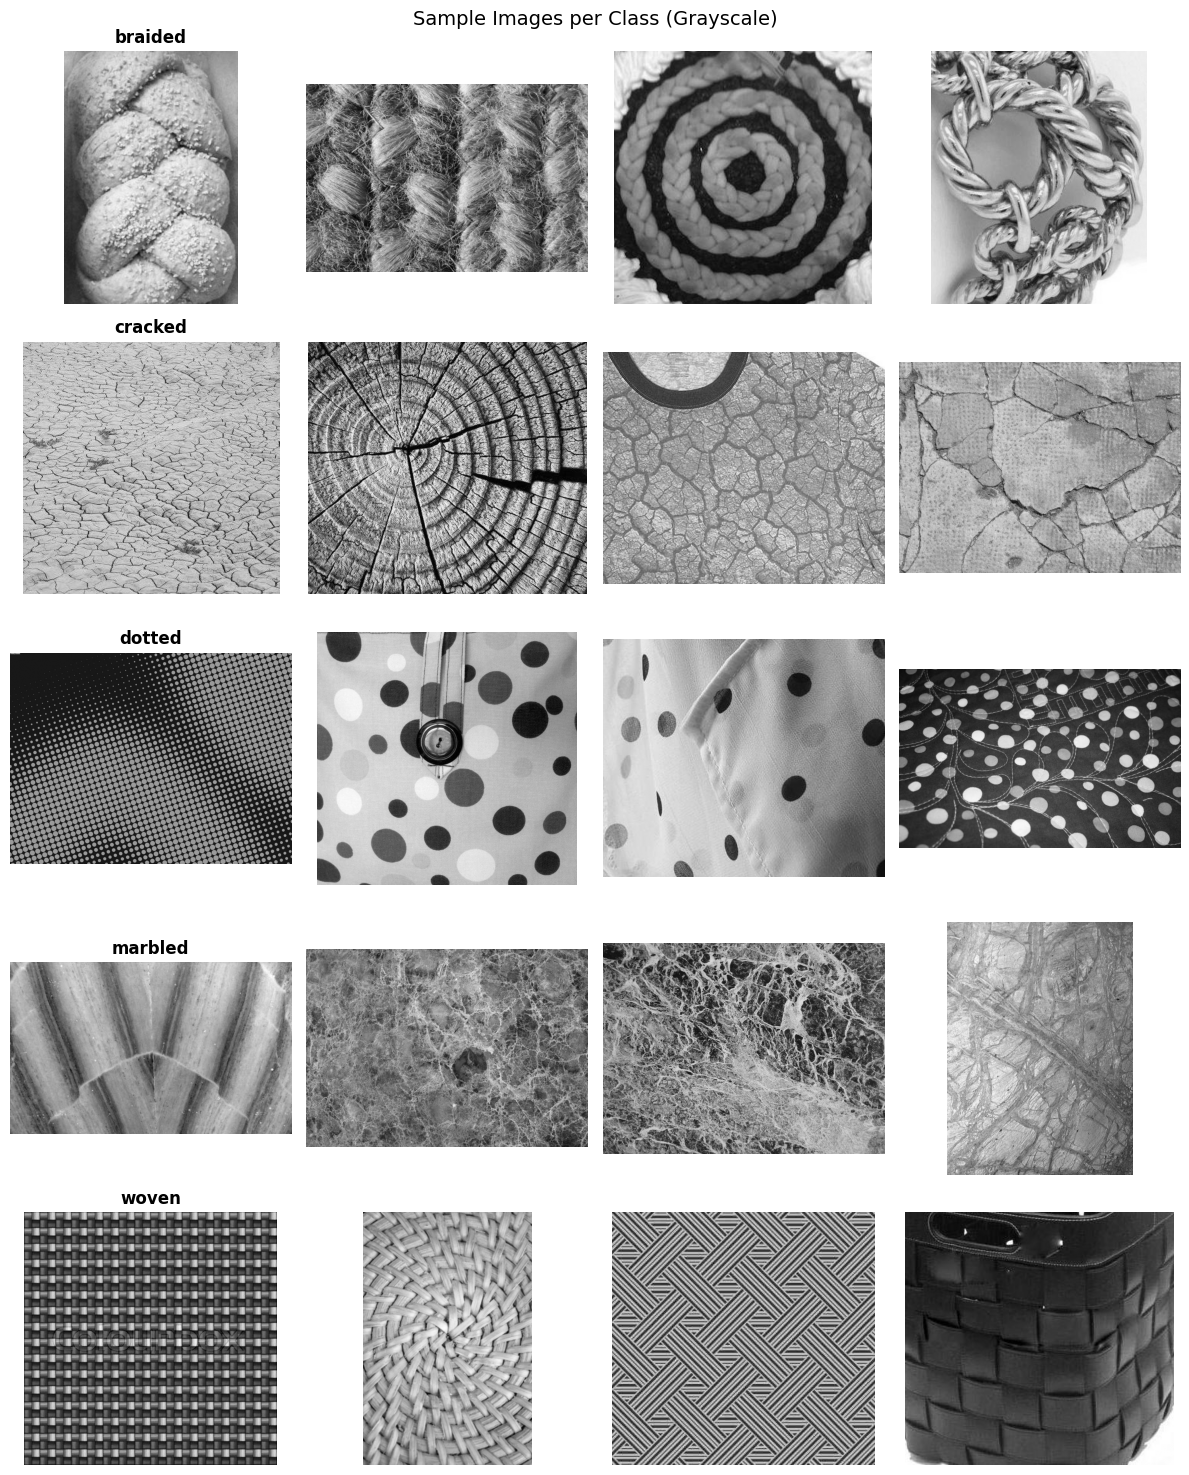

In [6]:
# Visualize sample images from each class
from PIL import Image

fig, axes = plt.subplots(len(SELECTED_CLASSES), 4, figsize=(12, 3*len(SELECTED_CLASSES)))
for i, cls in enumerate(SELECTED_CLASSES):
    imgs = glob.glob(os.path.join(DATA_ROOT, cls, '*.jpg'))[:4]
    for j, img_path in enumerate(imgs):
        img = Image.open(img_path).convert('L')  # grayscale
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(cls, fontsize=12, fontweight='bold')
plt.suptitle('Sample Images per Class (Grayscale)', fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

## 🖼️ 3. Preprocessing Pipeline

Preprocessing function defined.


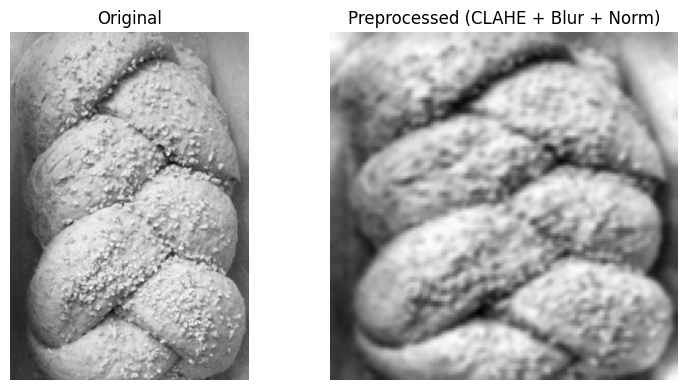

In [7]:
import cv2
import numpy as np
from skimage import filters, exposure
from PIL import Image

IMG_SIZE = 128  # resize all images to 128x128

def preprocess_image(img_path, size=IMG_SIZE):
    """
    Full preprocessing pipeline:
    1. Load as grayscale
    2. Resize
    3. Histogram Equalization (CLAHE)
    4. Gaussian blur for noise reduction
    5. Normalize to [0, 1]
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        img = np.array(Image.open(img_path).convert('L'))

    # Resize
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)

    # CLAHE histogram equalization
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    # Gaussian blur for noise reduction
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # Normalize to [0, 1]
    img = img.astype(np.float32) / 255.0
    return img

print('Preprocessing function defined.')

# Demo preprocessing
sample_path = glob.glob(os.path.join(DATA_ROOT, SELECTED_CLASSES[0], '*.jpg'))[0]
raw = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
processed = preprocess_image(sample_path)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(raw, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(processed, cmap='gray'); axes[1].set_title('Preprocessed (CLAHE + Blur + Norm)'); axes[1].axis('off')
plt.tight_layout(); plt.show()

In [8]:
from tqdm import tqdm

def load_dataset(data_root, selected_classes, size=IMG_SIZE):
    """Load all images, preprocess, and return X (images), y (labels), label_map"""
    X, y = [], []
    label_map = {cls: i for i, cls in enumerate(selected_classes)}

    for cls in selected_classes:
        img_paths = glob.glob(os.path.join(data_root, cls, '*.jpg'))
        img_paths += glob.glob(os.path.join(data_root, cls, '*.png'))
        print(f'Loading {cls}: {len(img_paths)} images')
        for p in tqdm(img_paths, desc=cls, leave=False):
            try:
                img = preprocess_image(p, size)
                X.append(img)
                y.append(label_map[cls])
            except Exception as e:
                pass

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64), label_map

X_all, y_all, label_map = load_dataset(DATA_ROOT, SELECTED_CLASSES)
print(f'\nDataset loaded: X={X_all.shape}, y={y_all.shape}')
print(f'Label map: {label_map}')
print(f'Class distribution: {np.bincount(y_all)}')

Loading braided: 120 images


Loading cracked: 120 images


Loading dotted: 120 images


Loading marbled: 120 images


Loading woven: 120 images



Dataset loaded: X=(600, 128, 128), y=(600,)
Label map: {'braided': 0, 'cracked': 1, 'dotted': 2, 'marbled': 3, 'woven': 4}
Class distribution: [120 120 120 120 120]


## 🔧 4. Feature Extraction for ML Models

In [9]:
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.util import img_as_ubyte
import numpy as np

def extract_glcm_features(img):
    """Extract GLCM texture features"""
    img_uint8 = img_as_ubyte(np.clip(img, 0, 1))
    distances = [1, 2]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    glcm = graycomatrix(img_uint8, distances=distances, angles=angles,
                        levels=256, symmetric=True, normed=True)
    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
    features = []
    for p in props:
        val = graycoprops(glcm, p)  # shape: (n_dist, n_angles)
        features.extend([val.mean(), val.std()])
    return np.array(features)  # 12 features

def extract_lbp_features(img, P=24, R=3):
    """Extract LBP histogram features"""
    img_uint8 = img_as_ubyte(np.clip(img, 0, 1))
    lbp = local_binary_pattern(img_uint8, P=P, R=R, method='uniform')
    n_bins = P + 2
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
    return hist  # 26 features

def extract_fourier_features(img):
    """Extract Fourier magnitude spectrum features"""
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude = 20 * np.log1p(np.abs(fshift))
    h, w = magnitude.shape
    cy, cx = h // 2, w // 2
    # Radial statistics in rings
    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X - cx)**2 + (Y - cy)**2).astype(int)
    features = []
    max_r = min(cy, cx)
    step = max_r // 8
    for r in range(0, max_r, step):
        ring_mask = (dist >= r) & (dist < r + step)
        ring_vals = magnitude[ring_mask]
        if len(ring_vals) > 0:
            features.extend([ring_vals.mean(), ring_vals.std()])
    return np.array(features[:16])  # 16 features

def extract_all_features(img):
    """Concatenate all ML features"""
    glcm = extract_glcm_features(img)
    lbp  = extract_lbp_features(img)
    fft  = extract_fourier_features(img)
    return np.concatenate([glcm, lbp, fft])

# Test feature extraction
test_feat = extract_all_features(X_all[0])
print(f'Feature vector size: {test_feat.shape[0]}')
print(f'  GLCM: 12, LBP: 26, Fourier: 16')

Feature vector size: 54
  GLCM: 12, LBP: 26, Fourier: 16


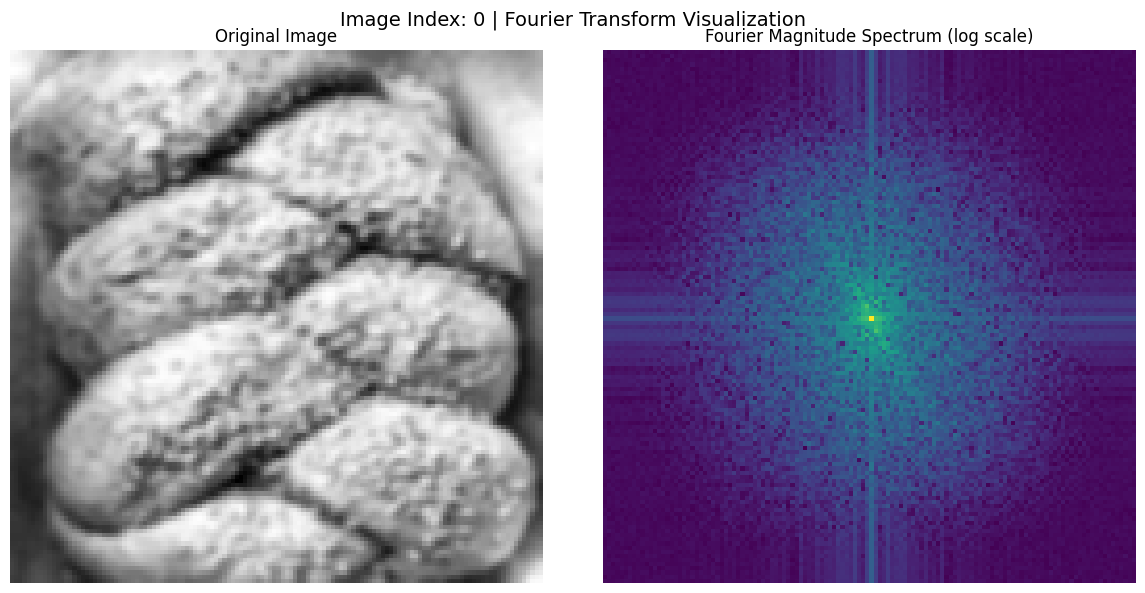

Image shape: (128, 128)
Pixel value range: [0.0824, 0.9882]


In [11]:
import matplotlib.pyplot as plt
from skimage.util import img_as_ubyte
import numpy as np

# ==================== Image + Fourier Transform Visualization ====================

# Select one sample image (you can change the index)
img_idx = 0
sample_img = X_all[img_idx] if 'X_all' in globals() else X_tr[img_idx]

# Make sure image is in proper format (grayscale, 0-1 range)
if len(sample_img.shape) == 3 and sample_img.shape[-1] == 3:
    sample_img = np.mean(sample_img, axis=2)  # convert to grayscale if RGB

sample_img = np.clip(sample_img, 0, 1)

# Compute Fourier Transform
f = np.fft.fft2(sample_img)
fshift = np.fft.fftshift(f)
magnitude = 20 * np.log1p(np.abs(fshift))

# Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(sample_img, cmap='gray')
axs[0].set_title('Original Image')
axs[0].axis('off')

axs[1].imshow(magnitude, cmap='viridis')
axs[1].set_title('Fourier Magnitude Spectrum (log scale)')
axs[1].axis('off')

plt.suptitle(f'Image Index: {img_idx} | Fourier Transform Visualization', fontsize=14)
plt.tight_layout()
plt.show()

# Optional: Print basic info
print(f"Image shape: {sample_img.shape}")
print(f"Pixel value range: [{sample_img.min():.4f}, {sample_img.max():.4f}]")

In [10]:
print('Extracting features for all images (this may take a few minutes)...')
feats = []
for img in tqdm(X_all, desc='Feature Extraction'):
    feats.append(extract_all_features(img))

X_features = np.array(feats, dtype=np.float32)
print(f'Feature matrix shape: {X_features.shape}')

Extracting features for all images (this may take a few minutes)...


Feature Extraction: 100%|██████████| 600/600 [00:36<00:00, 16.33it/s]

Feature matrix shape: (600, 54)


##  5. Metrics & Evaluation Utilities

In [17]:
def evaluate_model(y_true, y_pred, y_prob, model_name, stage_name, label_names=None, verbose=True):
    """Compute and return all metrics, save plots. Print metrics only if verbose=True."""
    if label_names is None:
        label_names = SELECTED_CLASSES

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)

    # AUC (one-vs-rest)
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    try:
        auc_score = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')
    except Exception:
        auc_score = 0.0

    # ---- PRINT ONLY IF VERBOSE ----
    if verbose:
        print(f'\n===== {stage_name} | {model_name} =====')
        print(f'  Accuracy  : {acc:.4f}')
        print(f'  Precision : {prec:.4f}')
        print(f'  Recall    : {rec:.4f}')
        print(f'  F1-Score  : {f1:.4f}')
        print(f'  AUC       : {auc_score:.4f}')

    # ---- Confusion Matrix + ROC (ALWAYS) ----
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=label_names, yticklabels=label_names, ax=axes[0]
    )
    axes[0].set_title(f'Confusion Matrix\n{stage_name} | {model_name}')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')

    # ROC Curves
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        axes[1].plot(
            fpr, tpr,
            color=colors[i % len(colors)],
            label=f'{label_names[i]} (AUC={roc_auc:.2f})'
        )

    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[1].set_title(f'ROC Curves\n{stage_name} | {model_name}')
    axes[1].set_xlabel('FPR')
    axes[1].set_ylabel('TPR')
    axes[1].legend(loc='lower right', fontsize=8)

    plt.tight_layout()
    safe_name = f"{stage_name}_{model_name}".replace(' ', '_')
    plt.savefig(f'metrics_{safe_name}.png', dpi=100, bbox_inches='tight')
    plt.show()

    metrics = {
        'accuracy': round(acc, 4),
        'precision': round(prec, 4),
        'recall': round(rec, 4),
        'f1': round(f1, 4),
        'auc': round(auc_score, 4),
    }

    if stage_name not in RESULTS:
        RESULTS[stage_name] = {}
    RESULTS[stage_name][model_name] = metrics

    return metrics

---
##  STAGE 1 — Baseline (No Augmentation)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

STAGE = 'Stage1_NoAug'

# --------------------------------------------------
# 1) Create index-based split ONLY ONCE
# --------------------------------------------------
indices = np.arange(len(y_all))

tr_idx, te_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=y_all,
    random_state=42
)

# --------------------------------------------------
# 2) Apply indices to ALL data (images, features, labels)
# --------------------------------------------------
X_tr_feat = X_features[tr_idx]
X_te_feat = X_features[te_idx]

X_tr_img  = X_all[tr_idx]
X_te_img  = X_all[te_idx]

y_tr = y_all[tr_idx]
y_te = y_all[te_idx]

# --------------------------------------------------
# 3) Scale ONLY the features (not images)
# --------------------------------------------------
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr_feat)
X_te_scaled = scaler.transform(X_te_feat)

# --------------------------------------------------
# 4) Check
# --------------------------------------------------
print(f'Train: {len(tr_idx)} | Test: {len(te_idx)}')
print(f'Train class dist: {np.bincount(y_tr)}')
print(f'Test  class dist: {np.bincount(y_te)}')

Train: 480 | Test: 120
Train class dist: [96 96 96 96 96]
Test  class dist: [24 24 24 24 24]


### Stage 1 – ML Models (SVM, k-NN, Random Forest)

Training SVM...


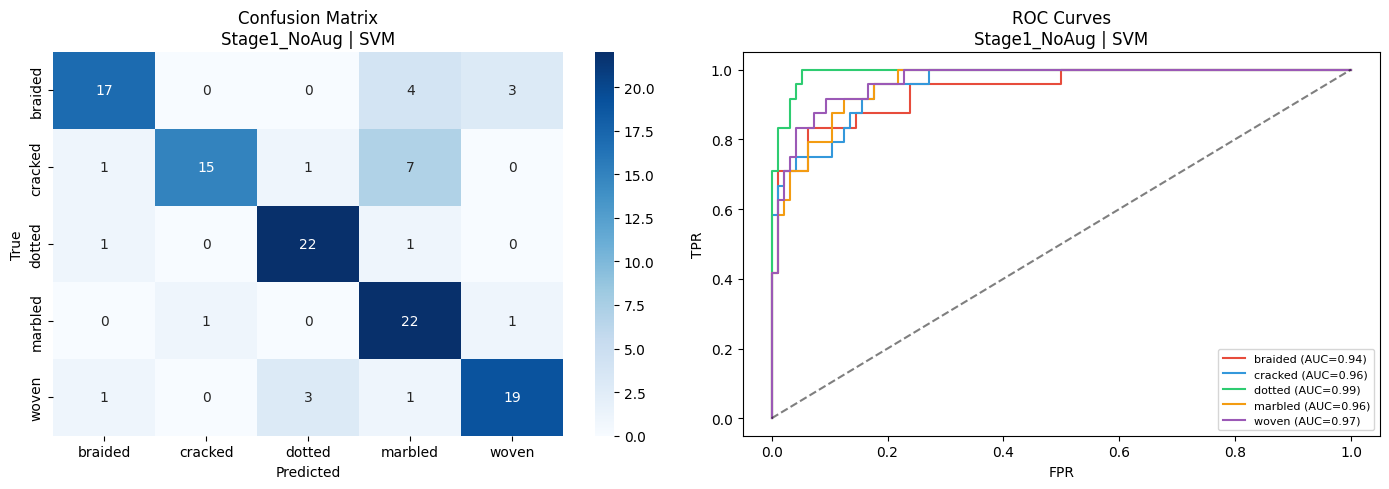

Training k-NN...


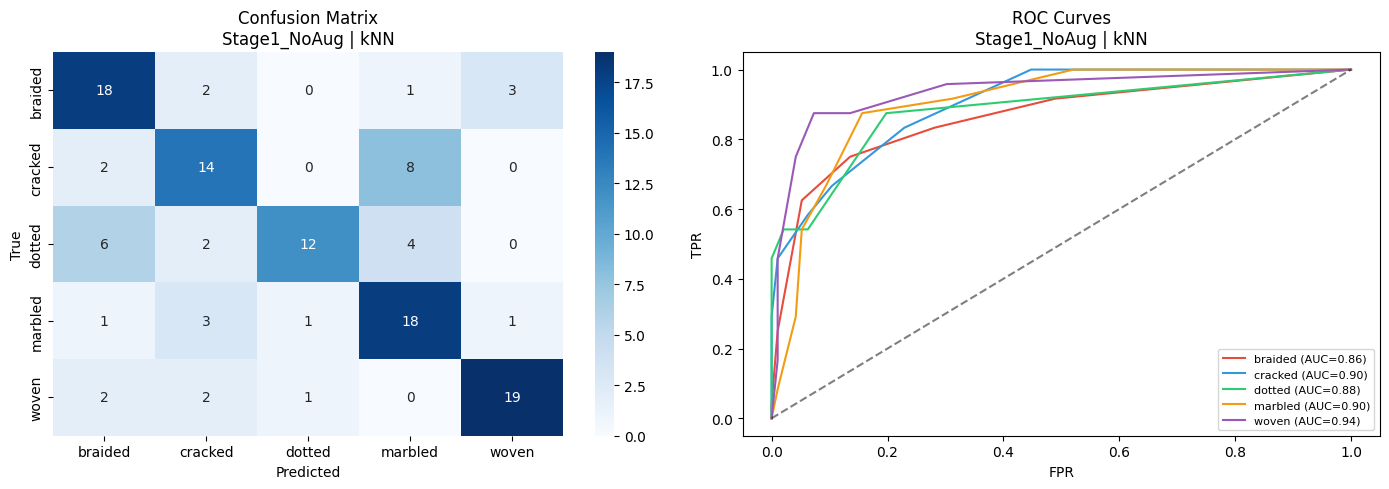

Training Random Forest...


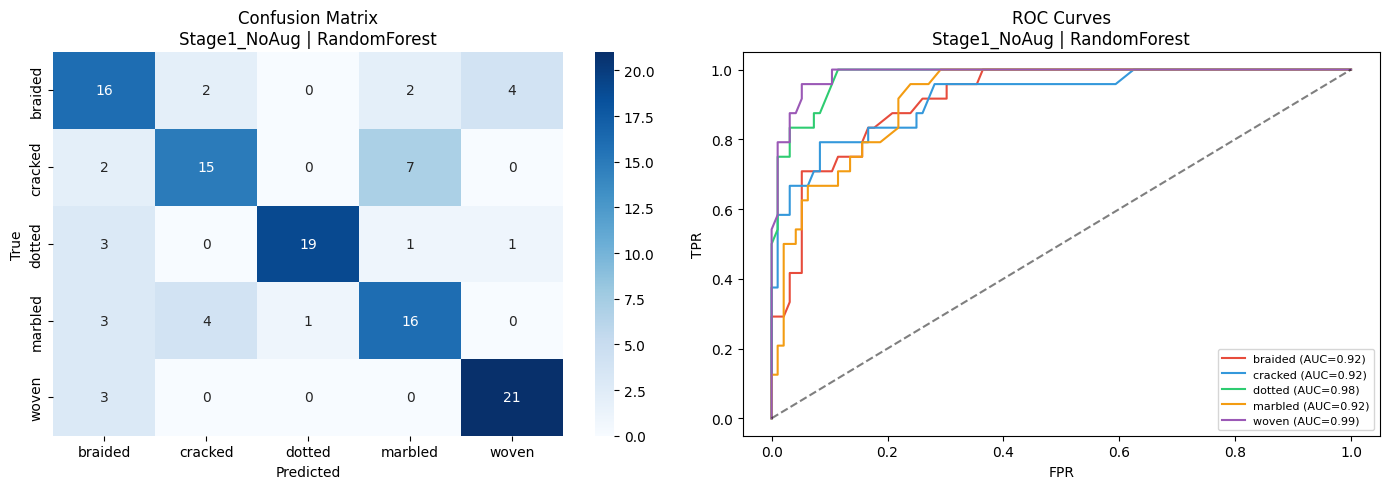

{'accuracy': 0.725,
 'precision': 0.736,
 'recall': 0.725,
 'f1': 0.7276,
 'auc': np.float64(0.9446)}

In [22]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# --- SVM ---
print('Training SVM...')
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm.fit(X_tr_scaled, y_tr)
y_pred_svm = svm.predict(X_te_scaled)
y_prob_svm = svm.predict_proba(X_te_scaled)
evaluate_model(y_te, y_pred_svm, y_prob_svm, 'SVM', STAGE,verbose=False)

# --- k-NN ---
print('Training k-NN...')
knn = KNeighborsClassifier(n_neighbors=7, metric='euclidean', n_jobs=-1)
knn.fit(X_tr_scaled, y_tr)
y_pred_knn = knn.predict(X_te_scaled)
y_prob_knn = knn.predict_proba(X_te_scaled)
evaluate_model(y_te, y_pred_knn, y_prob_knn, 'kNN', STAGE ,verbose=False)

# --- Random Forest ---
print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=200, max_depth=None, n_jobs=-1, random_state=42)
rf.fit(X_tr_scaled, y_tr)
y_pred_rf = rf.predict(X_te_scaled)
y_prob_rf = rf.predict_proba(X_te_scaled)
evaluate_model(y_te, y_pred_rf, y_prob_rf, 'RandomForest', STAGE ,verbose=False)

### Stage 1 – Deep Learning (CNN from Scratch + Transfer Learning)

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
import torchvision.models as models
import torchvision.transforms as T

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
EPOCHS_CNN = 30
BATCH_SIZE = 32
LR = 1e-3

# ---- Dataset helper ----
class TextureDataset(Dataset):
    def __init__(self, images, labels, transform=None, rgb=False):
        """
        images: (N, H, W) float32 numpy
        labels: (N,) int64 numpy
        """
        self.images = images
        self.labels = labels
        self.transform = transform
        self.rgb = rgb

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]  # (H, W)
        if self.rgb:
            img = np.stack([img, img, img], axis=0)  # (3, H, W)
        else:
            img = img[np.newaxis]  # (1, H, W)
        img_t = torch.tensor(img, dtype=torch.float32)
        if self.transform:
            img_t = self.transform(img_t)
        lbl_t = torch.tensor(self.labels[idx], dtype=torch.long)
        return img_t, lbl_t

def make_loaders(X_tr, y_tr, X_te, y_te, rgb=False, transform=None):
    tr_ds = TextureDataset(X_tr, y_tr, transform=transform, rgb=rgb)
    te_ds = TextureDataset(X_te, y_te, rgb=rgb)
    tr_ld = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    te_ld = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    return tr_ld, te_ld

print('DL utilities ready.')

Device: cuda
DL utilities ready.


In [24]:
# ---- CNN from Scratch ----
class TextureCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),  # 64
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 32
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),  # 16
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),  # 8
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(4),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 512), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

def train_dl_model(model, train_loader, test_loader, epochs=EPOCHS_CNN, lr=LR):
    model = model.to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()

        # Validate
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, lbls in test_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                out = model(imgs)
                correct += (out.argmax(1) == lbls).sum().item()
                total += lbls.size(0)
        val_acc = correct / total
        history['train_loss'].append(total_loss / len(train_loader))
        history['val_acc'].append(val_acc)

        if epoch % 5 == 0:
            print(f'  Epoch {epoch:3d}/{epochs} | Loss: {history["train_loss"][-1]:.4f} | Val Acc: {val_acc:.4f}')

    return model, history

def get_dl_predictions(model, test_loader):
    model.eval()
    all_preds, all_probs, all_true = [], [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(DEVICE)
            out = model(imgs)
            probs = torch.softmax(out, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)
            all_preds.extend(preds)
            all_probs.extend(probs)
            all_true.extend(lbls.numpy())
    return np.array(all_true), np.array(all_preds), np.array(all_probs)

def plot_training_history(history, model_name, stage_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], 'b-o', markersize=3)
    axes[0].set_title(f'Training Loss – {model_name}'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[1].plot(history['val_acc'], 'g-o', markersize=3)
    axes[1].set_title(f'Validation Accuracy – {model_name}'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    plt.suptitle(f'{stage_name} | {model_name}', fontsize=12)
    plt.tight_layout(); plt.show()

print('CNN model class defined.')

CNN model class defined.


In [25]:
# ============================================================
# EfficientNet-B3 — Two-Phase Fine-Tuning Helper
# Phase 1: frozen backbone, train head only  → fast baseline
# Phase 2: full unfreeze at very low LR      → the big accuracy jump
# ============================================================
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

EPOCHS_PHASE1 = 10   # head-only warmup
EPOCHS_PHASE2 = 20   # full fine-tune

def build_efficientnet(num_classes):
    model = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
    # Freeze entire backbone
    for param in model.parameters():
        param.requires_grad = False
    # Replace classifier head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(in_features, num_classes)
    )
    return model

def train_efficientnet_two_phase(X_tr, y_tr, X_te, y_te, stage_label):
    """
    Two-phase EfficientNet-B3 fine-tuning.
    Returns (model, phase2_history, train_loader, test_loader).
    """
    tr_ld, te_ld = make_loaders(X_tr, y_tr, X_te, y_te, rgb=True)
    model = build_efficientnet(NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()

    # ── Phase 1: head only ──────────────────────────────────────────
    print(f'  [{stage_label}] Phase 1: head only ({EPOCHS_PHASE1} epochs)...')
    opt1 = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                       lr=1e-3, weight_decay=1e-4)
    sch1 = optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=EPOCHS_PHASE1)

    for epoch in range(1, EPOCHS_PHASE1 + 1):
        model.train()
        for imgs, lbls in tr_ld:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            opt1.zero_grad()
            criterion(model(imgs), lbls).backward()
            opt1.step()
        sch1.step()
        if epoch % 5 == 0:
            model.eval()
            correct = 0
            with torch.no_grad():
                for imgs, lbls in te_ld:
                    correct += (model(imgs.to(DEVICE)).argmax(1) == lbls.to(DEVICE)).sum().item()
            print(f'    Epoch {epoch:3d} | Val Acc: {correct / len(y_te):.4f}')

    # ── Phase 2: unfreeze all, fine-tune at very low LR ────────────
    print(f'  [{stage_label}] Phase 2: full fine-tune ({EPOCHS_PHASE2} epochs)...')
    for param in model.parameters():
        param.requires_grad = True

    opt2 = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
    sch2 = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=EPOCHS_PHASE2)

    history = {'train_loss': [], 'val_acc': []}
    for epoch in range(1, EPOCHS_PHASE2 + 1):
        model.train()
        total_loss = 0
        for imgs, lbls in tr_ld:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            opt2.zero_grad()
            loss = criterion(model(imgs), lbls)
            loss.backward(); opt2.step()
            total_loss += loss.item()
        sch2.step()

        model.eval()
        correct = 0
        with torch.no_grad():
            for imgs, lbls in te_ld:
                correct += (model(imgs.to(DEVICE)).argmax(1) == lbls.to(DEVICE)).sum().item()
        val_acc = correct / len(y_te)
        history['train_loss'].append(total_loss / len(tr_ld))
        history['val_acc'].append(val_acc)
        if epoch % 5 == 0:
            print(f'    Epoch {epoch:3d}/{EPOCHS_PHASE2} | Loss: {history["train_loss"][-1]:.4f} | Val Acc: {val_acc:.4f}')

    return model, history, tr_ld, te_ld

print('EfficientNet-B3 two-phase fine-tuning helper defined.')


EfficientNet-B3 two-phase fine-tuning helper defined.



Training CNN from Scratch (Stage 1)...
  Epoch   5/30 | Loss: 1.1877 | Val Acc: 0.5583
  Epoch  10/30 | Loss: 0.8670 | Val Acc: 0.5583
  Epoch  15/30 | Loss: 0.5208 | Val Acc: 0.6500
  Epoch  20/30 | Loss: 0.3234 | Val Acc: 0.6500
  Epoch  25/30 | Loss: 0.1947 | Val Acc: 0.7000
  Epoch  30/30 | Loss: 0.1422 | Val Acc: 0.7083


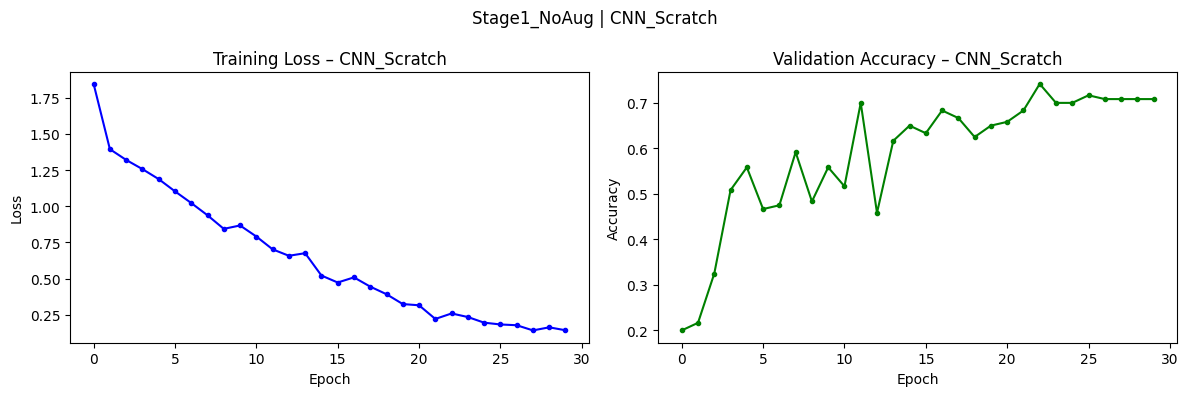

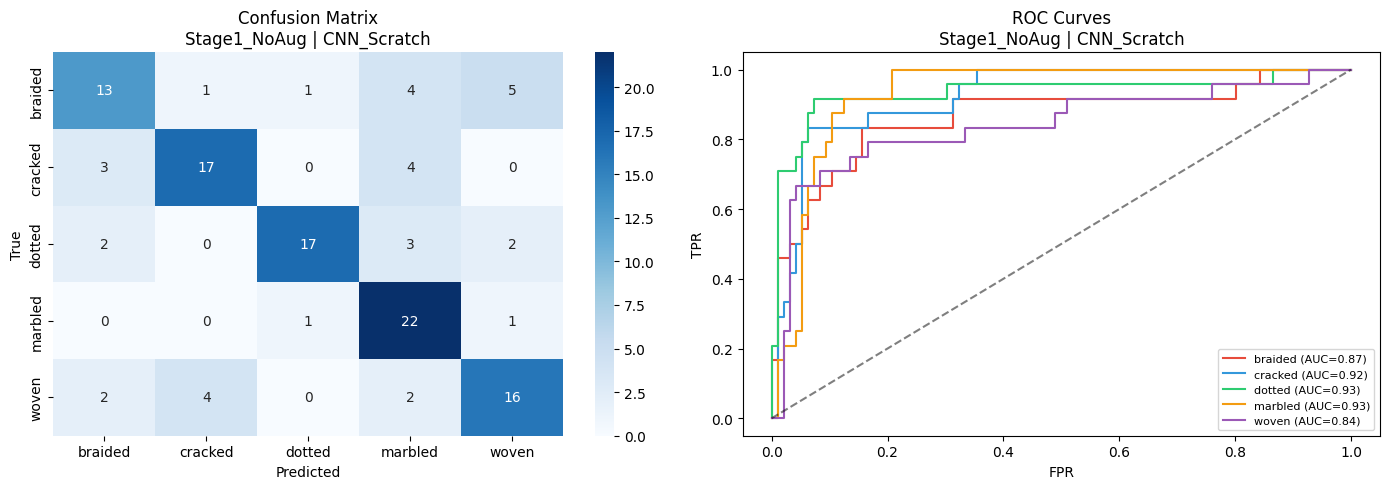

{'accuracy': 0.7083,
 'precision': 0.7225,
 'recall': 0.7083,
 'f1': 0.7066,
 'auc': np.float64(0.8992)}

In [27]:
# Train CNN from Scratch — Stage 1
print('\nTraining CNN from Scratch (Stage 1)...')
tr_ld_s1, te_ld_s1 = make_loaders(X_tr_img, y_tr, X_te_img, y_te, rgb=False)

cnn_s1 = TextureCNN(num_classes=NUM_CLASSES)
cnn_s1, hist_cnn_s1 = train_dl_model(cnn_s1, tr_ld_s1, te_ld_s1, epochs=EPOCHS_CNN)
plot_training_history(hist_cnn_s1, 'CNN_Scratch', STAGE)

y_true_cnn, y_pred_cnn, y_prob_cnn = get_dl_predictions(cnn_s1, te_ld_s1)
evaluate_model(y_true_cnn, y_pred_cnn, y_prob_cnn, 'CNN_Scratch', STAGE,verbose=False)


Training ResNet18 TL (Stage 1)...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


  Epoch   5/30 | Loss: 0.0826 | Val Acc: 0.8083
  Epoch  10/30 | Loss: 0.0981 | Val Acc: 0.8417
  Epoch  15/30 | Loss: 0.0537 | Val Acc: 0.8833
  Epoch  20/30 | Loss: 0.0031 | Val Acc: 0.9083
  Epoch  25/30 | Loss: 0.0054 | Val Acc: 0.9083
  Epoch  30/30 | Loss: 0.0015 | Val Acc: 0.9167


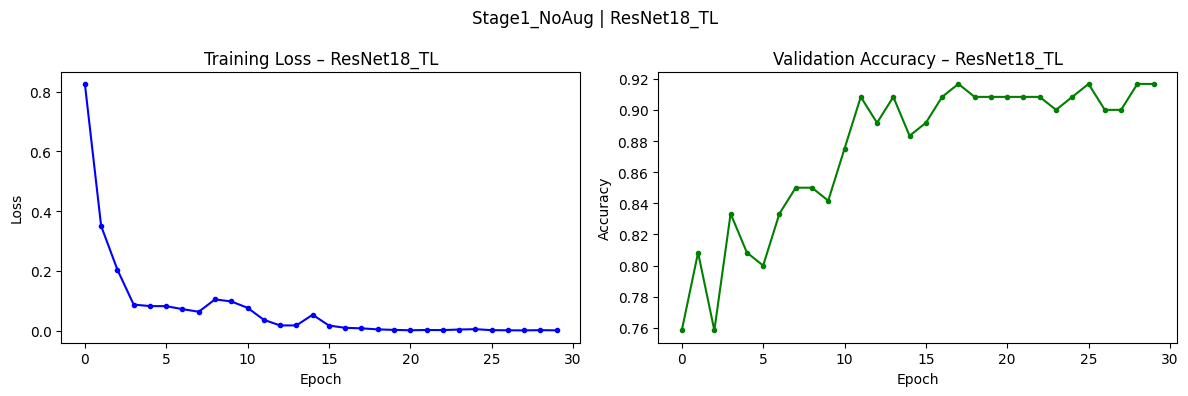

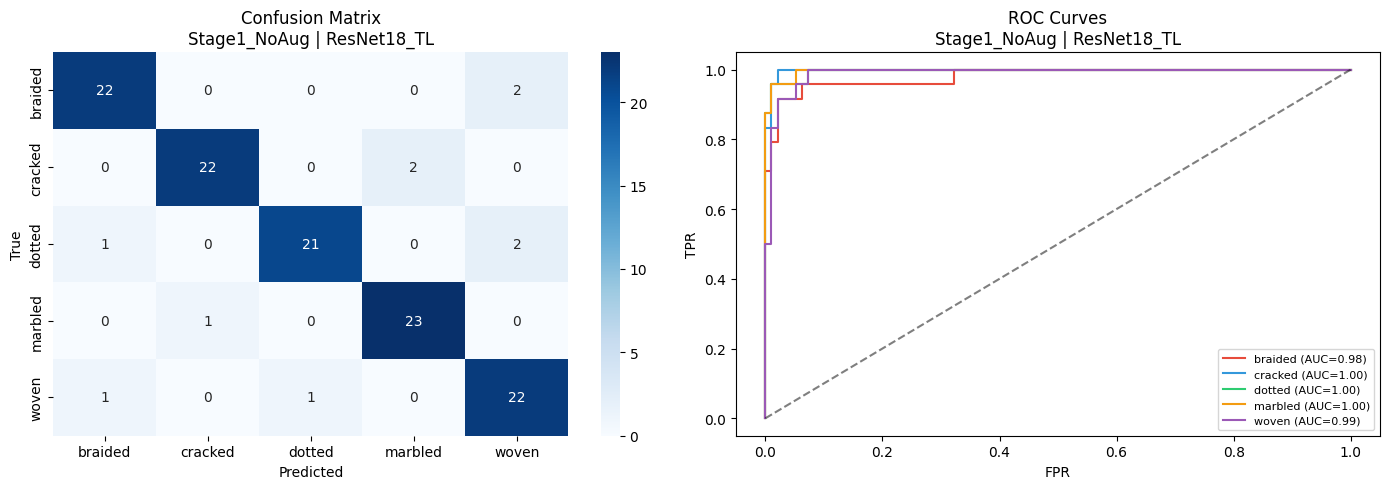


Training EfficientNet-B3 (Stage 1 — No Augmentation)...
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 187MB/s]


  [Stage1_NoAug] Phase 1: head only (10 epochs)...
    Epoch   5 | Val Acc: 0.8167
    Epoch  10 | Val Acc: 0.8167
  [Stage1_NoAug] Phase 2: full fine-tune (20 epochs)...
    Epoch   5/20 | Loss: 0.3608 | Val Acc: 0.8750
    Epoch  10/20 | Loss: 0.2137 | Val Acc: 0.8750
    Epoch  15/20 | Loss: 0.1512 | Val Acc: 0.8750
    Epoch  20/20 | Loss: 0.1600 | Val Acc: 0.8917


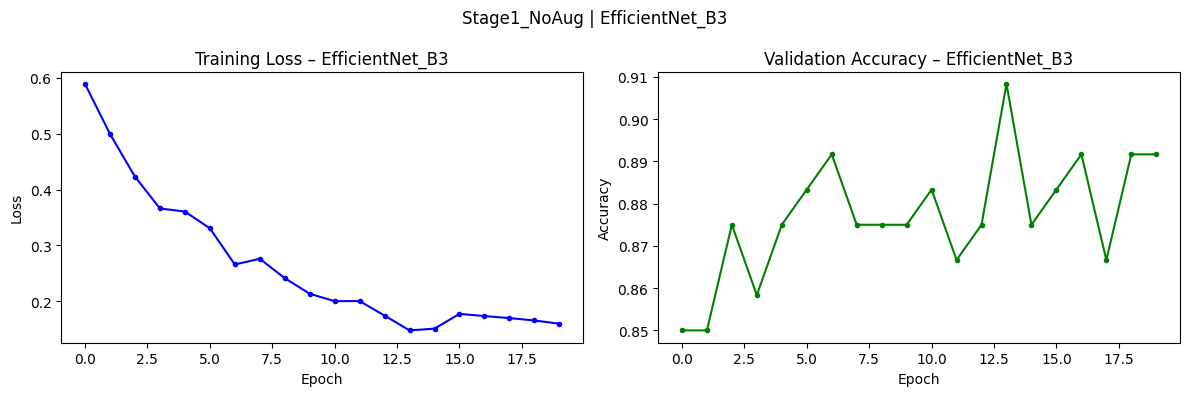

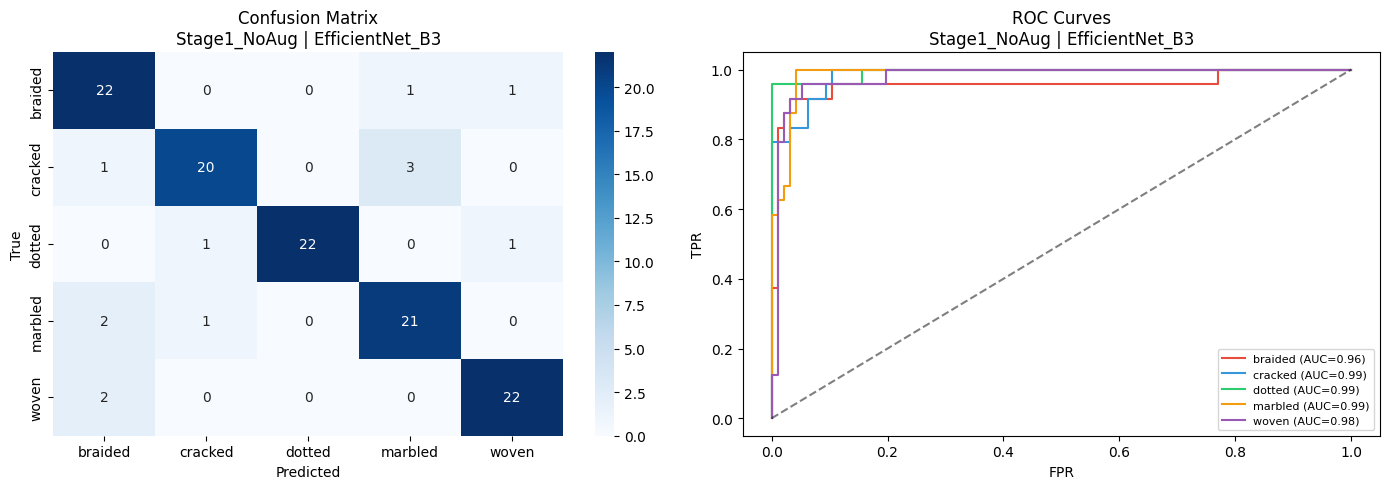

{'accuracy': 0.8917,
 'precision': 0.8961,
 'recall': 0.8917,
 'f1': 0.8925,
 'auc': np.float64(0.9804)}

In [28]:
# Transfer Learning — Stage 1 (ResNet18 kept + NEW EfficientNet-B3)
# ── ResNet18 (unchanged baseline) ──────────────────────────────────────────
print('\nTraining ResNet18 TL (Stage 1)...')
tr_ld_s1_rgb, te_ld_s1_rgb = make_loaders(X_tr_img, y_tr, X_te_img, y_te, rgb=True)

resnet = models.resnet18(weights='IMAGENET1K_V1')
for param in resnet.parameters():
    param.requires_grad = False
for param in resnet.layer3.parameters():
    param.requires_grad = True
for param in resnet.layer4.parameters():
    param.requires_grad = True
resnet.fc = nn.Linear(resnet.fc.in_features, NUM_CLASSES)

resnet_s1, hist_resnet_s1 = train_dl_model(resnet, tr_ld_s1_rgb, te_ld_s1_rgb,
                                             epochs=EPOCHS_CNN, lr=5e-4)
plot_training_history(hist_resnet_s1, 'ResNet18_TL', STAGE)
y_true_rn, y_pred_rn, y_prob_rn = get_dl_predictions(resnet_s1, te_ld_s1_rgb)
evaluate_model(y_true_rn, y_pred_rn, y_prob_rn, 'ResNet18_TL', STAGE,verbose=False)

# ── EfficientNet-B3 Two-Phase Fine-Tuning ──────────────────────────────────
print('\nTraining EfficientNet-B3 (Stage 1 — No Augmentation)...')
effnet_s1, hist_eff_s1, tr_ld_eff_s1, te_ld_eff_s1 = train_efficientnet_two_phase(
    X_tr_img, y_tr, X_te_img, y_te, 'Stage1_NoAug'
)
plot_training_history(hist_eff_s1, 'EfficientNet_B3', STAGE)
y_true_e1, y_pred_e1, y_prob_e1 = get_dl_predictions(effnet_s1, te_ld_eff_s1)
evaluate_model(y_true_e1, y_pred_e1, y_prob_e1, 'EfficientNet_B3', STAGE,verbose=False)


---
##  STAGE 2 — Classical Data Augmentation

In [29]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

STAGE = 'Stage2_ClassicalAug'

# Classical augmentation pipeline
AUG_PIPELINE = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=45, p=0.7),
    A.RandomCrop(height=112, width=112, p=0.5),
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    A.GaussNoise(p=0.4),
    A.GaussianBlur(blur_limit=3, p=0.3),
    A.ElasticTransform(alpha=1, sigma=50, p=0.3),
])

def augment_dataset(X, y, n_aug_per_image=3):
    """
    Apply augmentation to all images and concatenate with originals.
    Returns augmented X, y.
    """
    X_aug_list, y_aug_list = [X.copy()], [y.copy()]
    for _ in range(n_aug_per_image):
        batch_aug = []
        for img in tqdm(X, desc='Augmenting', leave=False):
            img_uint8 = (img * 255).astype(np.uint8)
            result = AUG_PIPELINE(image=img_uint8)
            aug = result['image'].astype(np.float32) / 255.0
            batch_aug.append(aug)
        X_aug_list.append(np.array(batch_aug))
        y_aug_list.append(y.copy())

    X_out = np.concatenate(X_aug_list, axis=0)
    y_out = np.concatenate(y_aug_list, axis=0)
    return X_out, y_out

print('Augmenting training data (3x)...')
X_tr_aug, y_tr_aug = augment_dataset(X_tr_img, y_tr, n_aug_per_image=3)
print(f'Augmented training set: {X_tr_aug.shape[0]} images (was {X_tr_img.shape[0]})')
print(f'Class distribution: {np.bincount(y_tr_aug)}')

Augmenting training data (3x)...


Augmented training set: 1920 images (was 480)
Class distribution: [384 384 384 384 384]


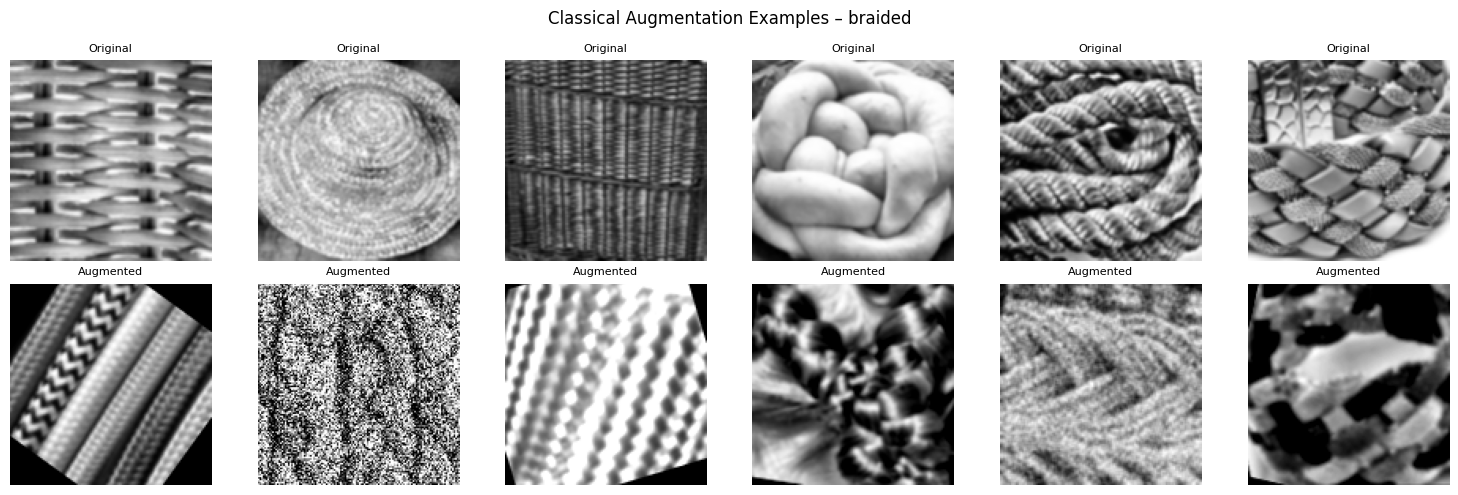

In [30]:
# Visualize augmented samples
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
orig_idx = np.where(y_tr == 0)[0][:6]
aug_idx  = np.where(y_tr_aug == 0)[0][-6:]

for j in range(6):
    axes[0, j].imshow(X_tr_img[orig_idx[j]], cmap='gray')
    axes[0, j].set_title('Original', fontsize=8); axes[0, j].axis('off')
    axes[1, j].imshow(X_tr_aug[aug_idx[j]], cmap='gray')
    axes[1, j].set_title('Augmented', fontsize=8); axes[1, j].axis('off')
plt.suptitle(f'Classical Augmentation Examples – {SELECTED_CLASSES[0]}')
plt.tight_layout(); plt.show()

In [31]:
# Extract features from augmented training set for ML models
print('Extracting features for augmented training data...')
feats_aug = []
for img in tqdm(X_tr_aug, desc='Feature Ext (Aug)'):
    feats_aug.append(extract_all_features(img))
X_tr_aug_feat = np.array(feats_aug, dtype=np.float32)

scaler_s2 = StandardScaler()
X_tr_aug_scaled = scaler_s2.fit_transform(X_tr_aug_feat)
X_te_s2_scaled  = scaler_s2.transform(X_te_feat)

print(f'Augmented feature matrix: {X_tr_aug_feat.shape}')

Extracting features for augmented training data...


Feature Ext (Aug): 100%|██████████| 1920/1920 [01:49<00:00, 17.52it/s]

Augmented feature matrix: (1920, 54)



Training ML Models (Stage 2)...


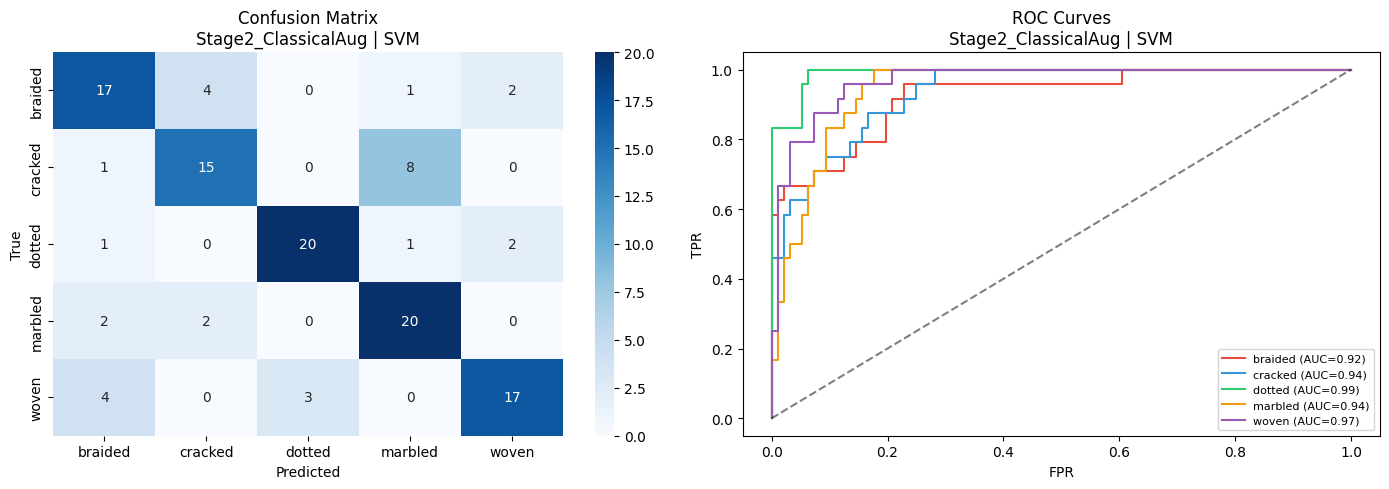

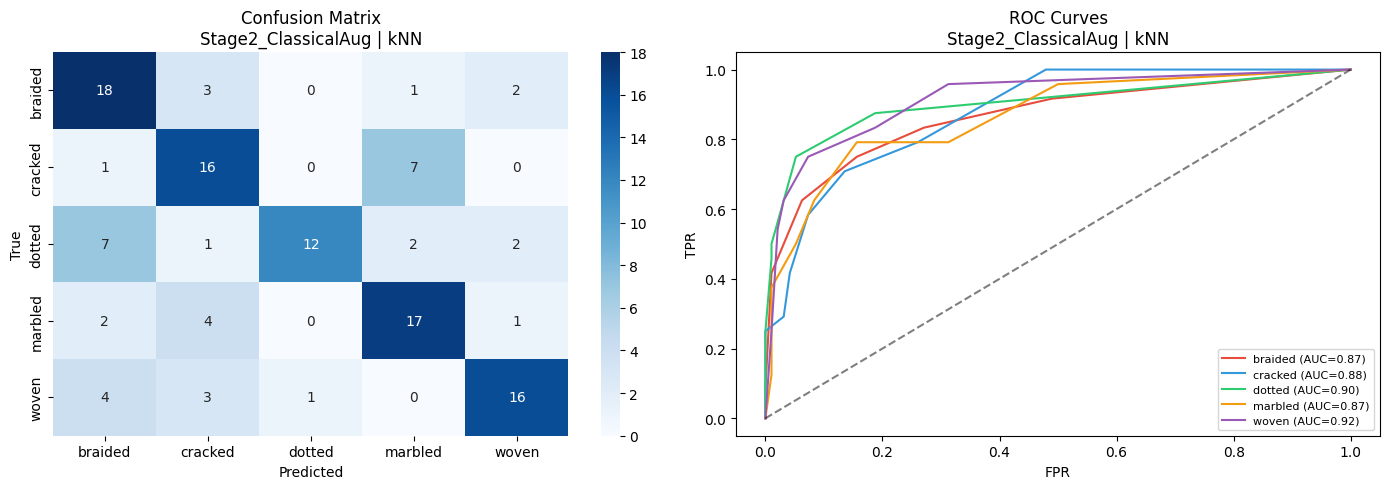

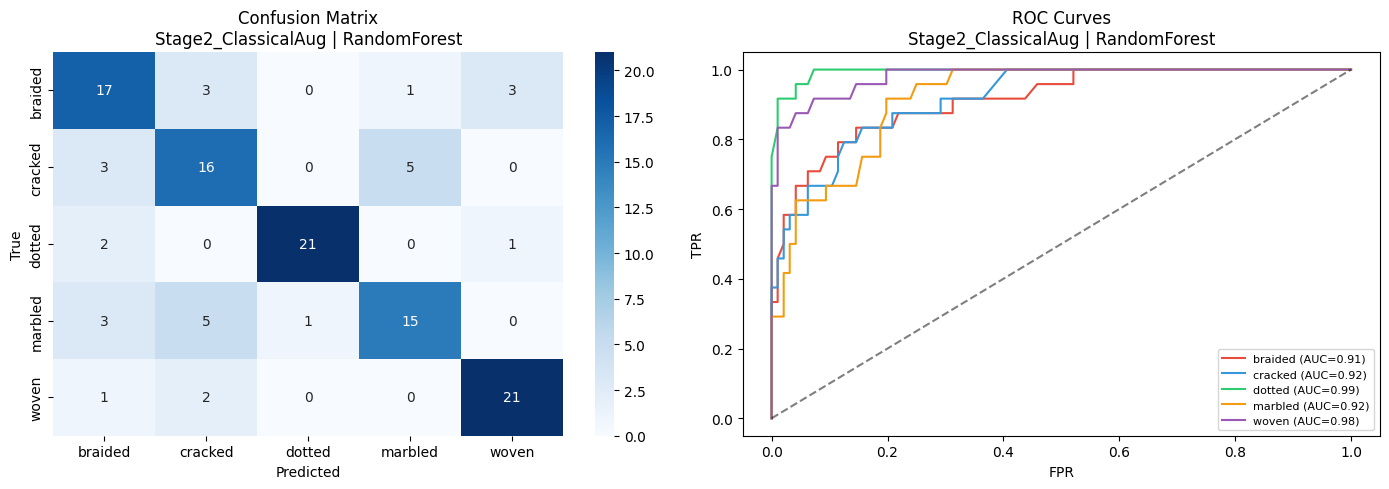

{'accuracy': 0.75,
 'precision': 0.7556,
 'recall': 0.75,
 'f1': 0.7514,
 'auc': np.float64(0.9446)}

In [32]:
# Stage 2 – ML Models
print('\nTraining ML Models (Stage 2)...')

svm_s2 = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm_s2.fit(X_tr_aug_scaled, y_tr_aug)
evaluate_model(y_te, svm_s2.predict(X_te_s2_scaled),
               svm_s2.predict_proba(X_te_s2_scaled), 'SVM', STAGE,verbose=False)

knn_s2 = KNeighborsClassifier(n_neighbors=7, n_jobs=-1)
knn_s2.fit(X_tr_aug_scaled, y_tr_aug)
evaluate_model(y_te, knn_s2.predict(X_te_s2_scaled),
               knn_s2.predict_proba(X_te_s2_scaled), 'kNN', STAGE ,verbose=False)

rf_s2 = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
rf_s2.fit(X_tr_aug_scaled, y_tr_aug)
evaluate_model(y_te, rf_s2.predict(X_te_s2_scaled),
               rf_s2.predict_proba(X_te_s2_scaled), 'RandomForest', STAGE,verbose=False)


Training CNN Scratch (Stage 2)...
  Epoch   5/30 | Loss: 1.4127 | Val Acc: 0.4500
  Epoch  10/30 | Loss: 1.2457 | Val Acc: 0.5417
  Epoch  15/30 | Loss: 0.9693 | Val Acc: 0.6167
  Epoch  20/30 | Loss: 0.7660 | Val Acc: 0.6833
  Epoch  25/30 | Loss: 0.6049 | Val Acc: 0.7417
  Epoch  30/30 | Loss: 0.5134 | Val Acc: 0.7333


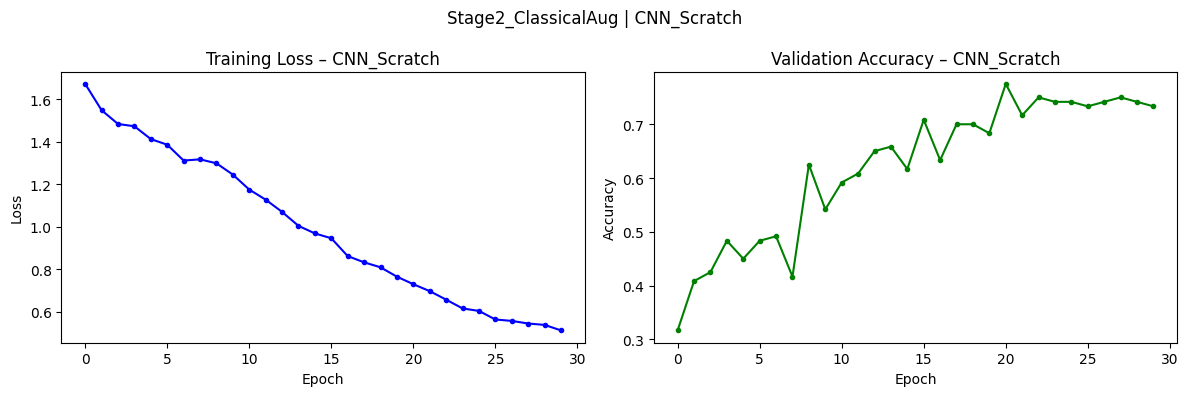

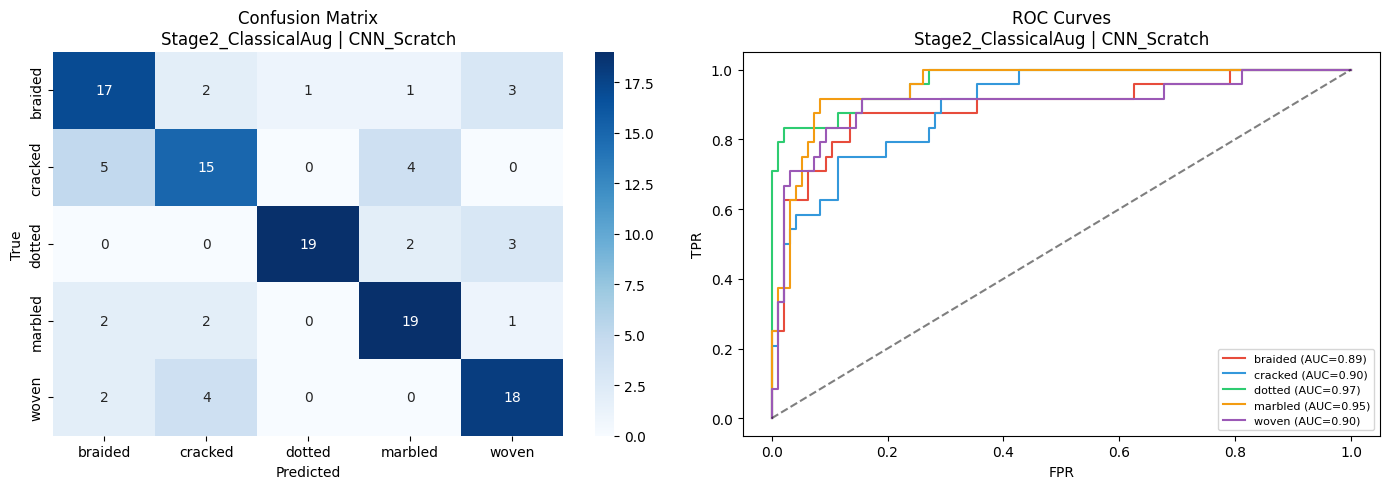


Training ResNet18 TL (Stage 2)...
  Epoch   5/30 | Loss: 0.2847 | Val Acc: 0.8750
  Epoch  10/30 | Loss: 0.0816 | Val Acc: 0.8083
  Epoch  15/30 | Loss: 0.0251 | Val Acc: 0.8667
  Epoch  20/30 | Loss: 0.0057 | Val Acc: 0.8750
  Epoch  25/30 | Loss: 0.0025 | Val Acc: 0.8833
  Epoch  30/30 | Loss: 0.0015 | Val Acc: 0.8750


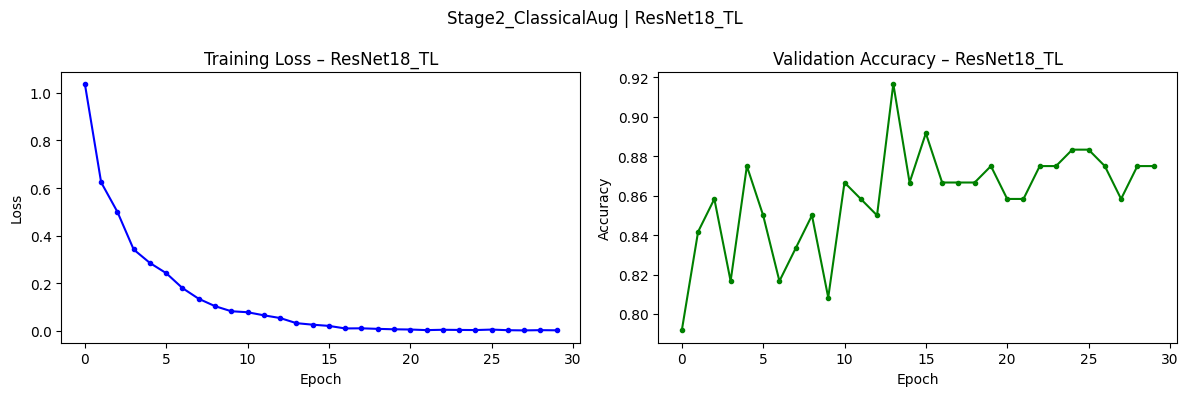

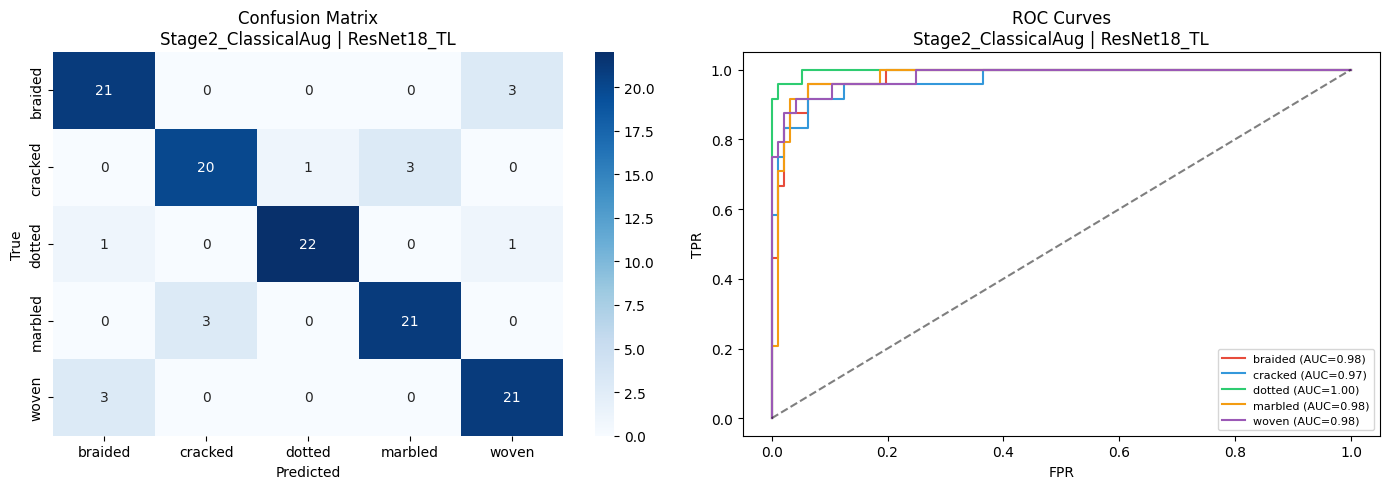


Training EfficientNet-B3 (Stage 2 — Classical Augmentation)...
  [Stage2_ClassicalAug] Phase 1: head only (10 epochs)...
    Epoch   5 | Val Acc: 0.8917
    Epoch  10 | Val Acc: 0.9167
  [Stage2_ClassicalAug] Phase 2: full fine-tune (20 epochs)...
    Epoch   5/20 | Loss: 0.4845 | Val Acc: 0.8917
    Epoch  10/20 | Loss: 0.3366 | Val Acc: 0.9083
    Epoch  15/20 | Loss: 0.2873 | Val Acc: 0.9000
    Epoch  20/20 | Loss: 0.2602 | Val Acc: 0.8917


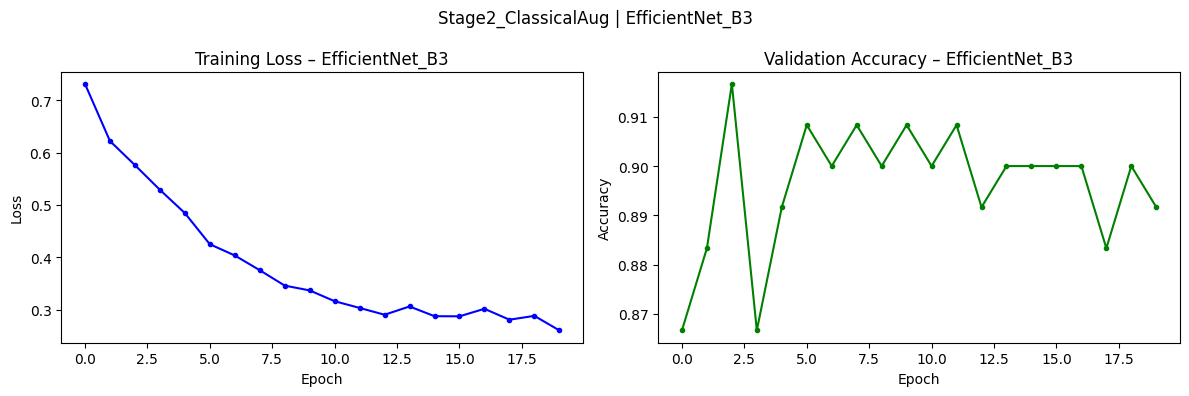

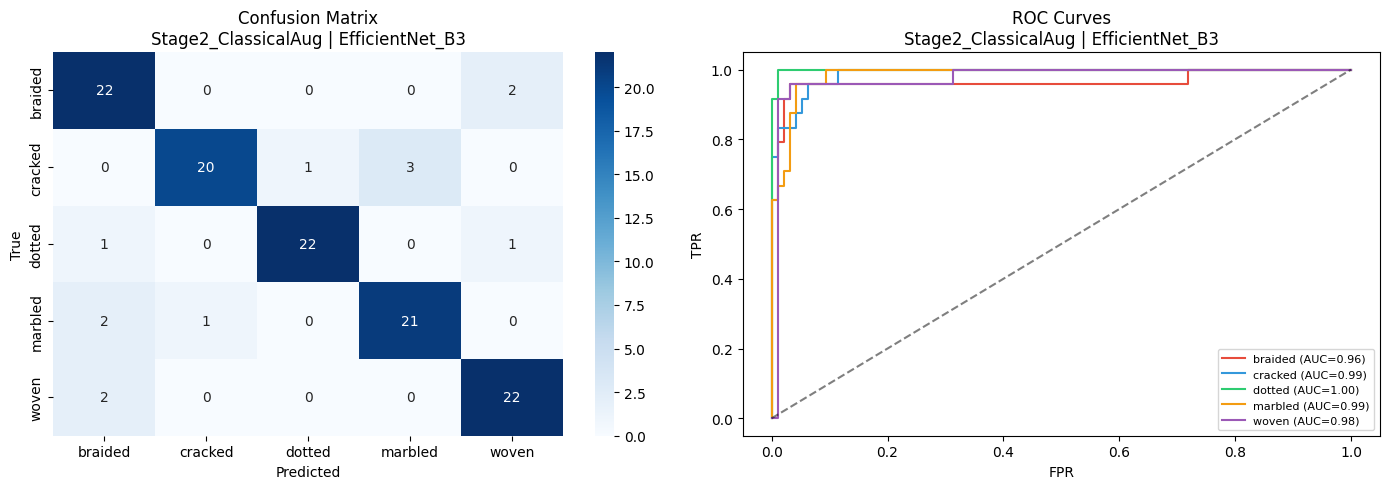

{'accuracy': 0.8917,
 'precision': 0.8957,
 'recall': 0.8917,
 'f1': 0.8922,
 'auc': np.float64(0.9827)}

In [34]:
# Stage 2 – DL Models (CNN Scratch + ResNet18 + EfficientNet-B3)
print('\nTraining CNN Scratch (Stage 2)...')
tr_ld_s2, te_ld_s2 = make_loaders(X_tr_aug, y_tr_aug, X_te_img, y_te, rgb=False)

cnn_s2 = TextureCNN(num_classes=NUM_CLASSES)
cnn_s2, hist_cnn_s2 = train_dl_model(cnn_s2, tr_ld_s2, te_ld_s2, epochs=EPOCHS_CNN)
plot_training_history(hist_cnn_s2, 'CNN_Scratch', STAGE)
y_true_c2, y_pred_c2, y_prob_c2 = get_dl_predictions(cnn_s2, te_ld_s2)
evaluate_model(y_true_c2, y_pred_c2, y_prob_c2, 'CNN_Scratch', STAGE,verbose=False)

print('\nTraining ResNet18 TL (Stage 2)...')
tr_ld_s2_rgb, te_ld_s2_rgb = make_loaders(X_tr_aug, y_tr_aug, X_te_img, y_te, rgb=True)

resnet_s2 = models.resnet18(weights='IMAGENET1K_V1')
for param in resnet_s2.parameters():
    param.requires_grad = False
for param in resnet_s2.layer3.parameters():
    param.requires_grad = True
for param in resnet_s2.layer4.parameters():
    param.requires_grad = True
resnet_s2.fc = nn.Linear(resnet_s2.fc.in_features, NUM_CLASSES)

resnet_s2, hist_resnet_s2 = train_dl_model(resnet_s2, tr_ld_s2_rgb, te_ld_s2_rgb,
                                             epochs=EPOCHS_CNN, lr=5e-4)
plot_training_history(hist_resnet_s2, 'ResNet18_TL', STAGE)
y_true_r2, y_pred_r2, y_prob_r2 = get_dl_predictions(resnet_s2, te_ld_s2_rgb)
evaluate_model(y_true_r2, y_pred_r2, y_prob_r2, 'ResNet18_TL', STAGE,verbose=False)

# ── EfficientNet-B3 — Classical Augmentation ──────────────────────────────
print('\nTraining EfficientNet-B3 (Stage 2 — Classical Augmentation)...')
effnet_s2, hist_eff_s2, tr_ld_eff_s2, te_ld_eff_s2 = train_efficientnet_two_phase(
    X_tr_aug, y_tr_aug, X_te_img, y_te, 'Stage2_ClassicalAug'
)
plot_training_history(hist_eff_s2, 'EfficientNet_B3', STAGE)
y_true_e2, y_pred_e2, y_prob_e2 = get_dl_predictions(effnet_s2, te_ld_eff_s2)
evaluate_model(y_true_e2, y_pred_e2, y_prob_e2, 'EfficientNet_B3', STAGE,verbose=False)


---
##  STAGE 3 — GAN-Based Augmentation
### 3a. Train Conditional DCGAN

In [35]:
# ============================================================
# Conditional DCGAN for texture generation
# ============================================================

LATENT_DIM = 100
GAN_IMG_SIZE = 64  # GAN generates 64x64, then we resize to IMG_SIZE
GAN_EPOCHS = 80
GAN_BATCH  = 64
N_GAN_PER_CLASS = 100  # synthetic images to generate per class

class ConvGenerator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, num_classes=5, img_size=GAN_IMG_SIZE):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.init_size = img_size // 16
        self.fc = nn.Linear(latent_dim + num_classes, 256 * self.init_size ** 2)
        self.conv = nn.Sequential(
            nn.BatchNorm2d(256),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Tanh()
        )

    def forward(self, noise, labels):
        emb = self.label_emb(labels)
        x = torch.cat([noise, emb], dim=1)
        x = self.fc(x)
        x = x.view(x.size(0), 256, self.init_size, self.init_size)
        return self.conv(x)


class ConvDiscriminator(nn.Module):
    def __init__(self, num_classes=5, img_size=GAN_IMG_SIZE):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, img_size * img_size)
        self.conv = nn.Sequential(
            nn.Conv2d(2, 32, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
        )
        self.fc = nn.Linear(256 * (img_size // 16) ** 2, 1)

    def forward(self, img, labels):
        emb = self.label_emb(labels).view(labels.size(0), 1, img.size(2), img.size(3))
        x = torch.cat([img, emb], dim=1)
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


print('cDCGAN model classes defined.')

cDCGAN model classes defined.


In [36]:
# Prepare GAN training data (64x64, normalized to [-1, 1])
def prepare_gan_data(X, y, size=GAN_IMG_SIZE):
    imgs_resized = []
    for img in X:
        r = cv2.resize(img, (size, size))
        imgs_resized.append(r)
    X_r = np.array(imgs_resized, dtype=np.float32)
    X_r = (X_r - 0.5) / 0.5  # normalize to [-1, 1]
    return X_r, y

X_gan, y_gan = prepare_gan_data(X_tr_img, y_tr)

gan_ds = TextureDataset(X_gan, y_gan)
gan_ld = DataLoader(gan_ds, batch_size=GAN_BATCH, shuffle=True, num_workers=2, pin_memory=True)
print(f'GAN training set: {X_gan.shape}')

GAN training set: (480, 64, 64)


In [37]:
# ---- Train cDCGAN ----
G = ConvGenerator(LATENT_DIM, NUM_CLASSES, GAN_IMG_SIZE).to(DEVICE)
D = ConvDiscriminator(NUM_CLASSES, GAN_IMG_SIZE).to(DEVICE)

opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion_gan = nn.BCEWithLogitsLoss()

G_losses, D_losses = [], []

print(f'Training cDCGAN for {GAN_EPOCHS} epochs...')
for epoch in range(1, GAN_EPOCHS + 1):
    g_loss_ep, d_loss_ep = 0, 0

    for imgs, lbls in gan_ld:
        bs = imgs.size(0)
        real_imgs = imgs.to(DEVICE)
        lbls = lbls.to(DEVICE)

        real_labels = torch.ones(bs, 1, device=DEVICE)
        fake_labels = torch.zeros(bs, 1, device=DEVICE)

        # ---- Train D ----
        opt_D.zero_grad()
        d_real = D(real_imgs, lbls)
        d_real_loss = criterion_gan(d_real, real_labels)

        noise = torch.randn(bs, LATENT_DIM, device=DEVICE)
        fake_imgs = G(noise, lbls)
        d_fake = D(fake_imgs.detach(), lbls)
        d_fake_loss = criterion_gan(d_fake, fake_labels)

        d_loss = (d_real_loss + d_fake_loss) / 2
        d_loss.backward(); opt_D.step()

        # ---- Train G ----
        opt_G.zero_grad()
        noise = torch.randn(bs, LATENT_DIM, device=DEVICE)
        fake_imgs = G(noise, lbls)
        g_out = D(fake_imgs, lbls)
        g_loss = criterion_gan(g_out, real_labels)
        g_loss.backward(); opt_G.step()

        g_loss_ep += g_loss.item()
        d_loss_ep += d_loss.item()

    G_losses.append(g_loss_ep / len(gan_ld))
    D_losses.append(d_loss_ep / len(gan_ld))

    if epoch % 10 == 0:
        print(f'  Epoch {epoch:3d}/{GAN_EPOCHS} | G Loss: {G_losses[-1]:.4f} | D Loss: {D_losses[-1]:.4f}')

print('GAN training complete!')

Training cDCGAN for 80 epochs...
  Epoch  10/80 | G Loss: 2.3467 | D Loss: 0.2902
  Epoch  20/80 | G Loss: 1.3845 | D Loss: 0.4702
  Epoch  30/80 | G Loss: 1.3124 | D Loss: 0.5560
  Epoch  40/80 | G Loss: 1.3571 | D Loss: 0.5009
  Epoch  50/80 | G Loss: 1.6317 | D Loss: 0.5156
  Epoch  60/80 | G Loss: 1.5402 | D Loss: 0.4571
  Epoch  70/80 | G Loss: 1.4395 | D Loss: 0.4704
  Epoch  80/80 | G Loss: 1.6953 | D Loss: 0.4141
GAN training complete!


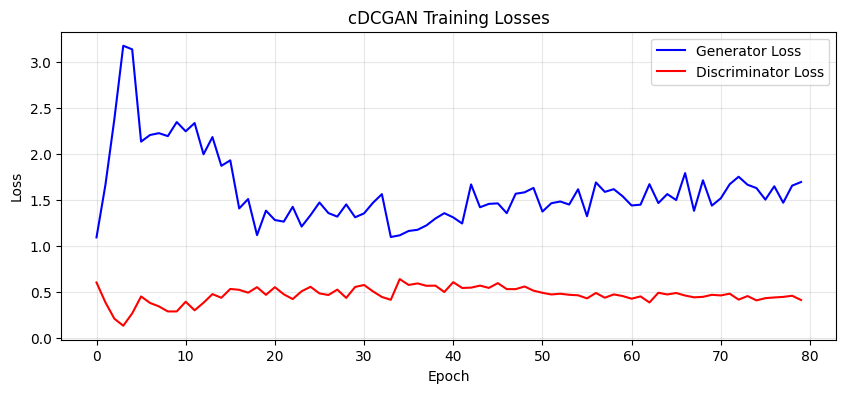

In [38]:
# Plot GAN training losses
plt.figure(figsize=(10, 4))
plt.plot(G_losses, label='Generator Loss', color='blue')
plt.plot(D_losses, label='Discriminator Loss', color='red')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('cDCGAN Training Losses')
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig('gan_training_loss.png', dpi=100, bbox_inches='tight')
plt.show()

Synthetic images: (500, 128, 128)


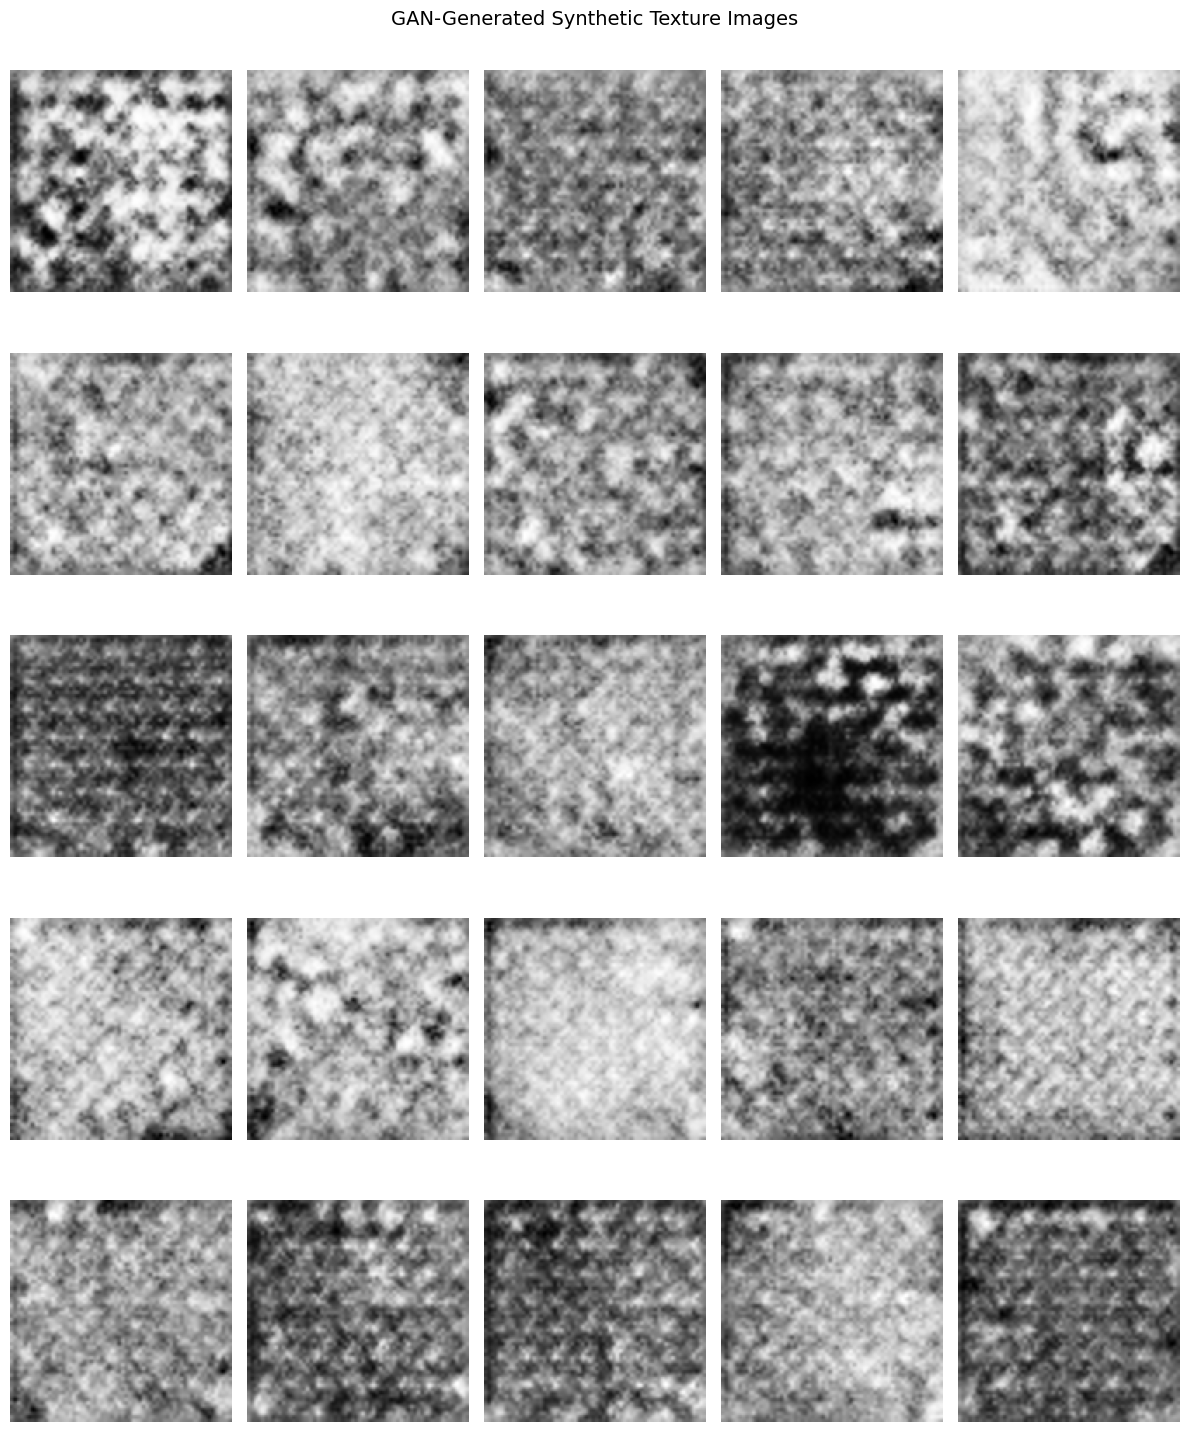

In [39]:
# ---- Generate Synthetic Images ----
G.eval()

def generate_synthetic(G, num_classes, n_per_class=N_GAN_PER_CLASS, out_size=IMG_SIZE):
    X_syn, y_syn = [], []
    with torch.no_grad():
        for cls_idx in range(num_classes):
            noise = torch.randn(n_per_class, LATENT_DIM, device=DEVICE)
            labels = torch.full((n_per_class,), cls_idx, dtype=torch.long, device=DEVICE)
            fake = G(noise, labels).cpu().numpy()  # (N, 1, 64, 64)
            for f in fake:
                img = f[0]  # (64, 64)
                img = (img + 1) / 2  # back to [0, 1]
                img = cv2.resize(img, (out_size, out_size))
                X_syn.append(img.astype(np.float32))
                y_syn.append(cls_idx)
    return np.array(X_syn), np.array(y_syn, dtype=np.int64)

X_syn, y_syn = generate_synthetic(G, NUM_CLASSES, N_GAN_PER_CLASS)
print(f'Synthetic images: {X_syn.shape}')

# Visualize GAN-generated images
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(12, 3 * NUM_CLASSES))
for i, cls in enumerate(SELECTED_CLASSES):
    cls_imgs = X_syn[y_syn == i][:5]
    for j in range(min(5, len(cls_imgs))):
        axes[i, j].imshow(cls_imgs[j], cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(cls, fontsize=10, rotation=0, labelpad=40)
plt.suptitle('GAN-Generated Synthetic Texture Images', fontsize=14)
plt.tight_layout()
plt.savefig('gan_generated_samples.png', dpi=100, bbox_inches='tight')
plt.show()

In [40]:
# Combine real training data + GAN synthetic data
STAGE = 'Stage3_GANAug'

X_tr_gan = np.concatenate([X_tr_img, X_syn], axis=0)
y_tr_gan  = np.concatenate([y_tr,    y_syn], axis=0)

print(f'Combined training set: {X_tr_gan.shape[0]} images')
print(f'Class distribution: {np.bincount(y_tr_gan)}')

Combined training set: 980 images
Class distribution: [196 196 196 196 196]


In [41]:
# Extract features from GAN-augmented training set
print('Extracting features for GAN-augmented training data...')
feats_gan = []
for img in tqdm(X_tr_gan, desc='Feature Ext (GAN)'):
    feats_gan.append(extract_all_features(img))
X_tr_gan_feat = np.array(feats_gan, dtype=np.float32)

scaler_s3 = StandardScaler()
X_tr_gan_scaled = scaler_s3.fit_transform(X_tr_gan_feat)
X_te_s3_scaled  = scaler_s3.transform(X_te_feat)

print(f'GAN-augmented feature matrix: {X_tr_gan_feat.shape}')

Extracting features for GAN-augmented training data...


Feature Ext (GAN): 100%|██████████| 980/980 [00:55<00:00, 17.62it/s]

GAN-augmented feature matrix: (980, 54)



Training ML Models (Stage 3 – GAN Aug)...


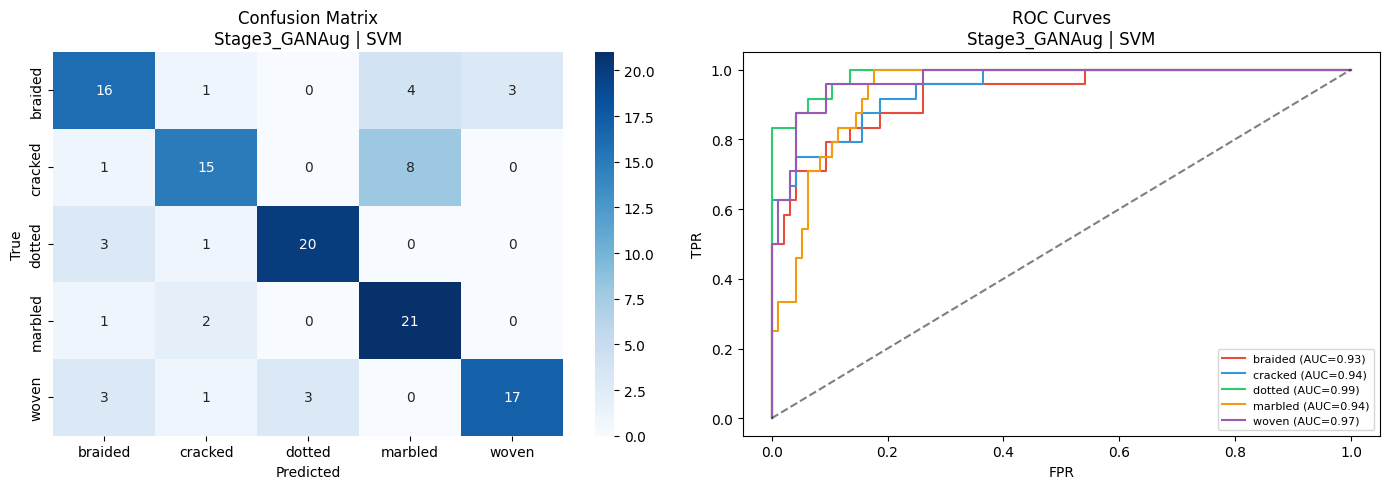

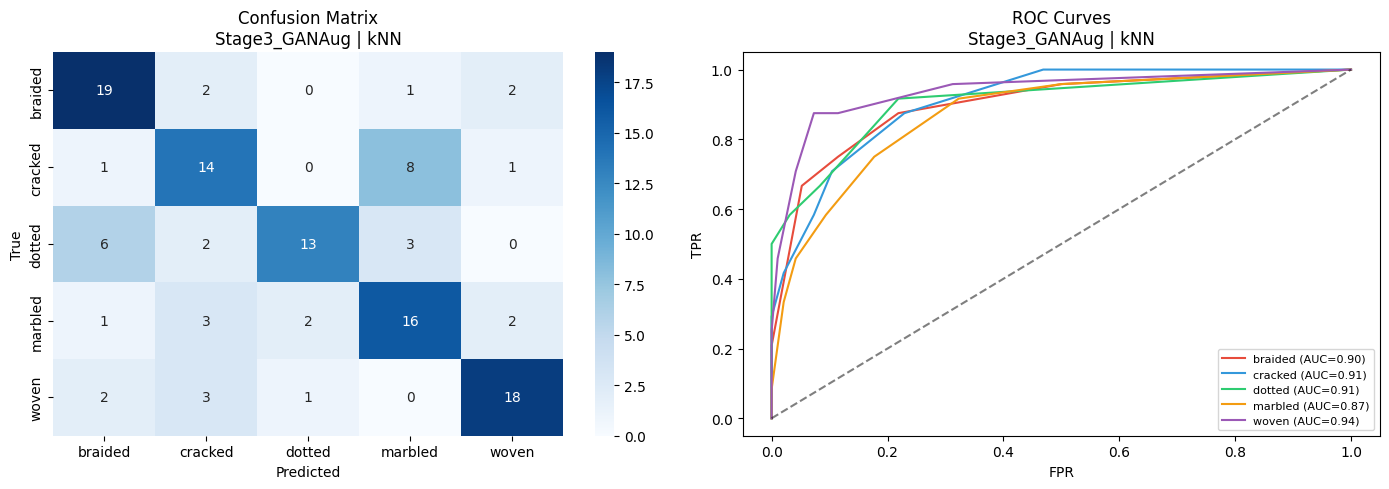

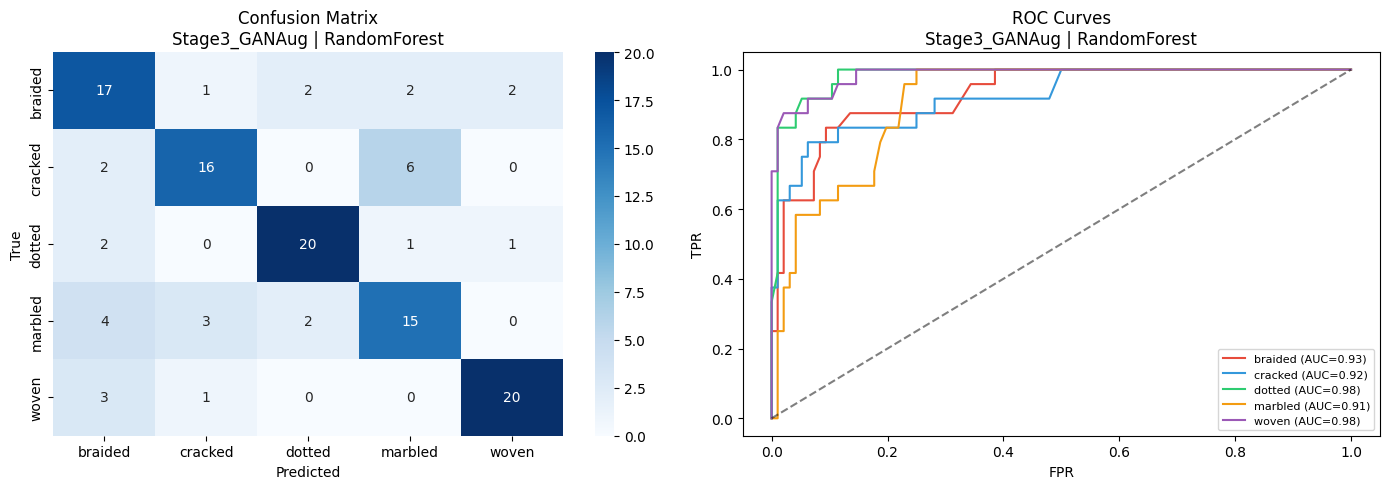

{'accuracy': 0.7333,
 'precision': 0.7394,
 'recall': 0.7333,
 'f1': 0.7349,
 'auc': np.float64(0.9453)}

In [42]:
# Stage 3 – ML Models
print('\nTraining ML Models (Stage 3 – GAN Aug)...')

svm_s3 = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm_s3.fit(X_tr_gan_scaled, y_tr_gan)
evaluate_model(y_te, svm_s3.predict(X_te_s3_scaled),
               svm_s3.predict_proba(X_te_s3_scaled), 'SVM', STAGE,verbose=False)

knn_s3 = KNeighborsClassifier(n_neighbors=7, n_jobs=-1)
knn_s3.fit(X_tr_gan_scaled, y_tr_gan)
evaluate_model(y_te, knn_s3.predict(X_te_s3_scaled),
               knn_s3.predict_proba(X_te_s3_scaled), 'kNN', STAGE,verbose=False)

rf_s3 = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
rf_s3.fit(X_tr_gan_scaled, y_tr_gan)
evaluate_model(y_te, rf_s3.predict(X_te_s3_scaled),
               rf_s3.predict_proba(X_te_s3_scaled), 'RandomForest', STAGE,verbose=False)


Training CNN Scratch (Stage 3)...
  Epoch   5/30 | Loss: 1.2059 | Val Acc: 0.4917
  Epoch  10/30 | Loss: 0.8111 | Val Acc: 0.6083
  Epoch  15/30 | Loss: 0.4115 | Val Acc: 0.5917
  Epoch  20/30 | Loss: 0.1915 | Val Acc: 0.6417
  Epoch  25/30 | Loss: 0.0618 | Val Acc: 0.7167
  Epoch  30/30 | Loss: 0.0476 | Val Acc: 0.7167


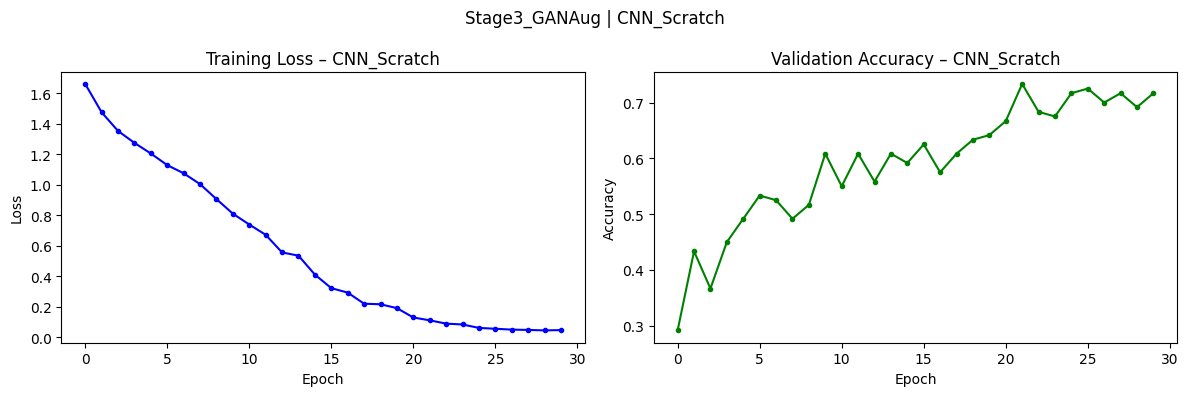

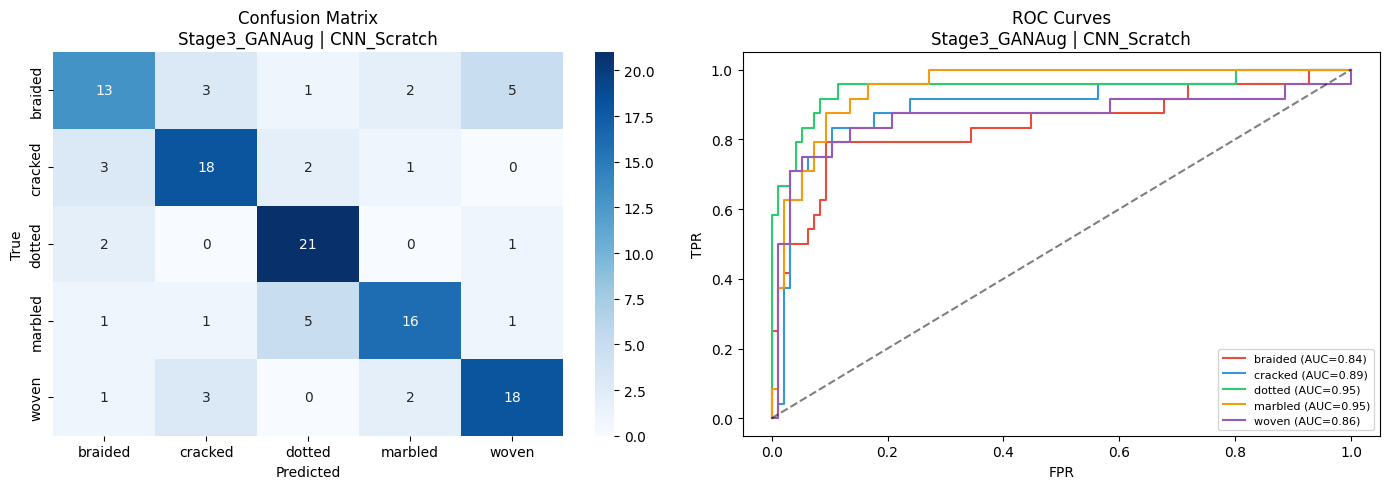


Training ResNet18 TL (Stage 3)...
  Epoch   5/30 | Loss: 0.1145 | Val Acc: 0.7917
  Epoch  10/30 | Loss: 0.0375 | Val Acc: 0.8917
  Epoch  15/30 | Loss: 0.0033 | Val Acc: 0.8833
  Epoch  20/30 | Loss: 0.0016 | Val Acc: 0.9000
  Epoch  25/30 | Loss: 0.0033 | Val Acc: 0.9000
  Epoch  30/30 | Loss: 0.0041 | Val Acc: 0.9000


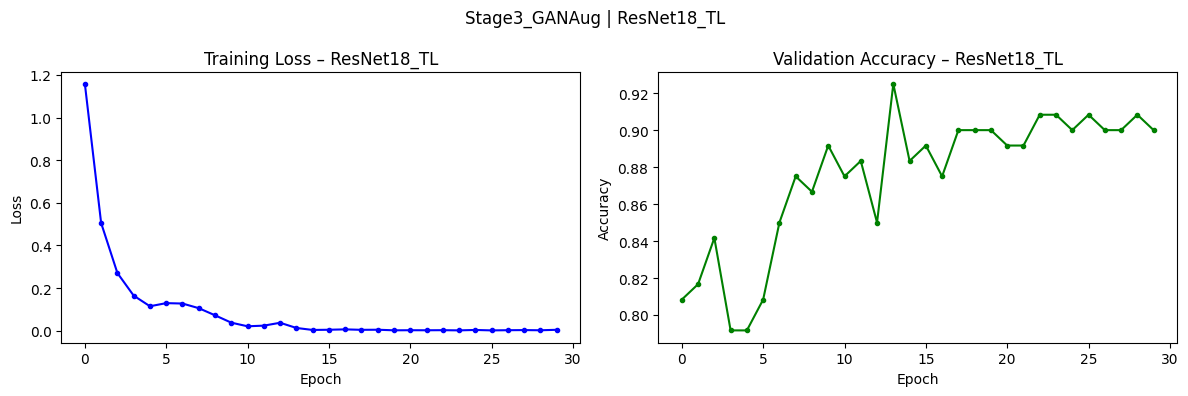

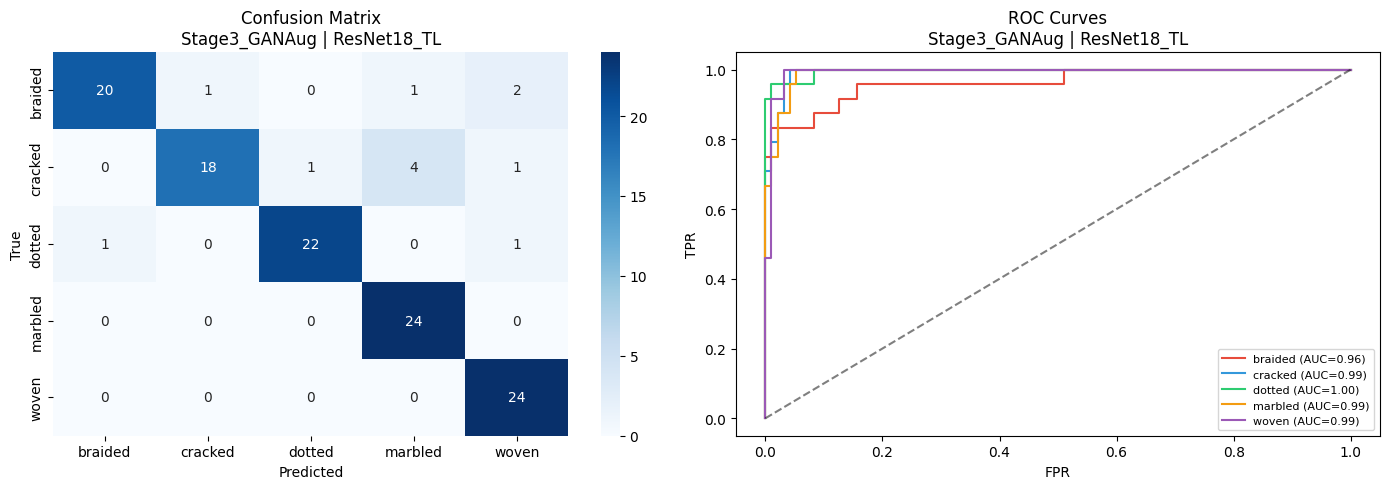


Training EfficientNet-B3 (Stage 3 — GAN Augmentation)...
  [Stage3_GANAug] Phase 1: head only (10 epochs)...
    Epoch   5 | Val Acc: 0.7417
    Epoch  10 | Val Acc: 0.7333
  [Stage3_GANAug] Phase 2: full fine-tune (20 epochs)...
    Epoch   5/20 | Loss: 0.7351 | Val Acc: 0.8000
    Epoch  10/20 | Loss: 0.5117 | Val Acc: 0.8583
    Epoch  15/20 | Loss: 0.4080 | Val Acc: 0.8500
    Epoch  20/20 | Loss: 0.4351 | Val Acc: 0.8333


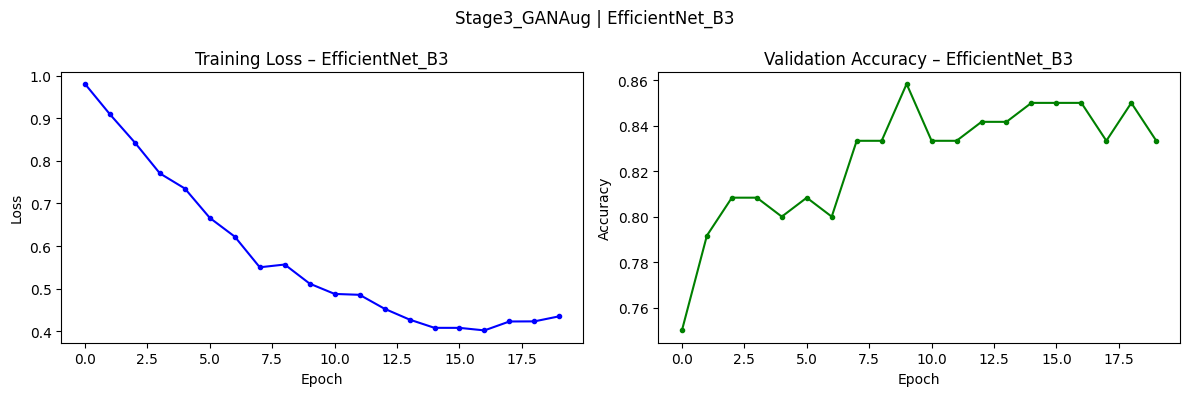

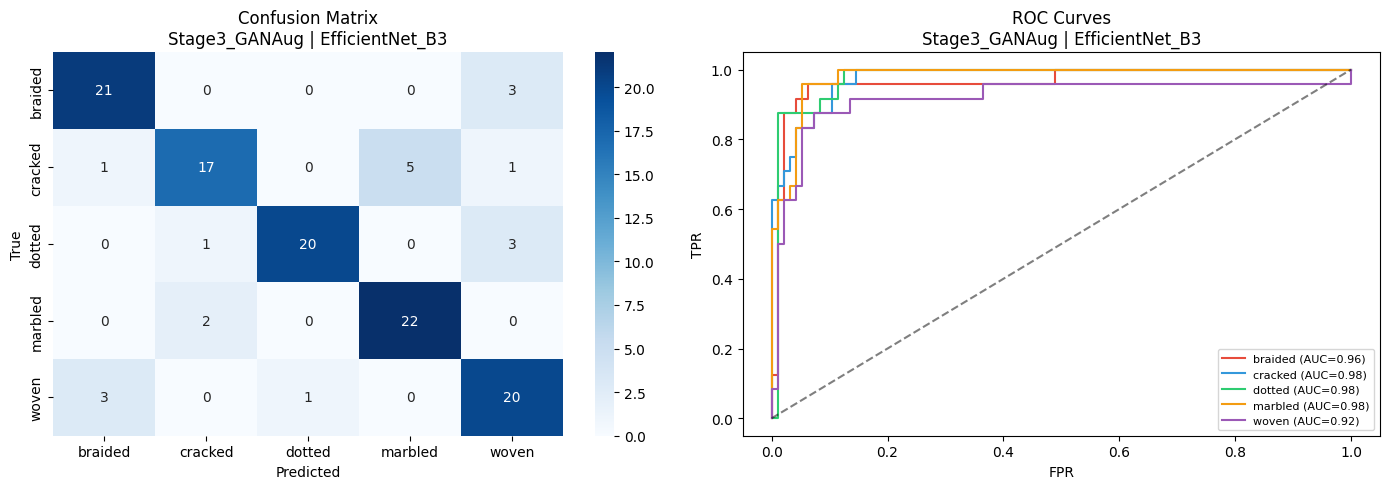

{'accuracy': 0.8333,
 'precision': 0.8396,
 'recall': 0.8333,
 'f1': 0.8332,
 'auc': np.float64(0.963)}

In [43]:
# Stage 3 – DL Models (CNN Scratch + ResNet18 + EfficientNet-B3)
print('\nTraining CNN Scratch (Stage 3)...')
tr_ld_s3, te_ld_s3 = make_loaders(X_tr_gan, y_tr_gan, X_te_img, y_te, rgb=False)

cnn_s3 = TextureCNN(num_classes=NUM_CLASSES)
cnn_s3, hist_cnn_s3 = train_dl_model(cnn_s3, tr_ld_s3, te_ld_s3, epochs=EPOCHS_CNN)
plot_training_history(hist_cnn_s3, 'CNN_Scratch', STAGE)
y_true_c3, y_pred_c3, y_prob_c3 = get_dl_predictions(cnn_s3, te_ld_s3)
evaluate_model(y_true_c3, y_pred_c3, y_prob_c3, 'CNN_Scratch', STAGE, verbose=False)

print('\nTraining ResNet18 TL (Stage 3)...')
tr_ld_s3_rgb, te_ld_s3_rgb = make_loaders(X_tr_gan, y_tr_gan, X_te_img, y_te, rgb=True)

resnet_s3 = models.resnet18(weights='IMAGENET1K_V1')
for param in resnet_s3.parameters():
    param.requires_grad = False
for param in resnet_s3.layer3.parameters():
    param.requires_grad = True
for param in resnet_s3.layer4.parameters():
    param.requires_grad = True
resnet_s3.fc = nn.Linear(resnet_s3.fc.in_features, NUM_CLASSES)

resnet_s3, hist_resnet_s3 = train_dl_model(resnet_s3, tr_ld_s3_rgb, te_ld_s3_rgb,
                                             epochs=EPOCHS_CNN, lr=5e-4)
plot_training_history(hist_resnet_s3, 'ResNet18_TL', STAGE)
y_true_r3, y_pred_r3, y_prob_r3 = get_dl_predictions(resnet_s3, te_ld_s3_rgb)
evaluate_model(y_true_r3, y_pred_r3, y_prob_r3, 'ResNet18_TL', STAGE, verbose=False)

# ── EfficientNet-B3 — GAN Augmentation ────────────────────────────────────
print('\nTraining EfficientNet-B3 (Stage 3 — GAN Augmentation)...')
effnet_s3, hist_eff_s3, tr_ld_eff_s3, te_ld_eff_s3 = train_efficientnet_two_phase(
    X_tr_gan, y_tr_gan, X_te_img, y_te, 'Stage3_GANAug'
)
plot_training_history(hist_eff_s3, 'EfficientNet_B3', STAGE)
y_true_e3, y_pred_e3, y_prob_e3 = get_dl_predictions(effnet_s3, te_ld_eff_s3)
evaluate_model(y_true_e3, y_pred_e3, y_prob_e3, 'EfficientNet_B3', STAGE, verbose=False)

---
## 📊 Final Comparison & Analysis

In [44]:
import pandas as pd

# Build comparison dataframe
rows = []
for stage, models_dict in RESULTS.items():
    for model_name, metrics in models_dict.items():
        rows.append({
            'Stage': stage,
            'Model': model_name,
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1': metrics['f1'],
            'AUC': metrics['auc'],
        })

df = pd.DataFrame(rows)

print('\n========== FULL RESULTS TABLE ==========')
print(df.to_string(index=False))




========== FULL RESULTS TABLE ==========
              Stage           Model  Precision  Recall     F1    AUC
       Stage1_NoAug             SVM     0.8177  0.7917 0.7914 0.9635
       Stage1_NoAug             kNN     0.6987  0.6750 0.6739 0.8974
       Stage1_NoAug    RandomForest     0.7360  0.7250 0.7276 0.9446
       Stage1_NoAug     CNN_Scratch     0.7225  0.7083 0.7066 0.8992
       Stage1_NoAug     ResNet18_TL     0.9188  0.9167 0.9169 0.9922
       Stage1_NoAug EfficientNet_B3     0.8961  0.8917 0.8925 0.9804
Stage2_ClassicalAug             SVM     0.7480  0.7417 0.7416 0.9526
Stage2_ClassicalAug             kNN     0.6939  0.6583 0.6593 0.8854
Stage2_ClassicalAug    RandomForest     0.7556  0.7500 0.7514 0.9446
Stage2_ClassicalAug     CNN_Scratch     0.7414  0.7333 0.7353 0.9227
Stage2_ClassicalAug     ResNet18_TL     0.8762  0.8750 0.8753 0.9816
Stage2_ClassicalAug EfficientNet_B3     0.8957  0.8917 0.8922 0.9827
      Stage3_GANAug             SVM     0.7545  0.7417 0.7418

In [50]:
import pandas as pd

rows = []

for stage, models in RESULTS.items():
    for model, metrics in models.items():
        rows.append({
            'Stage': stage,
            'Model': model,
            'Accuracy': metrics['accuracy'],
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1': metrics['f1'],
            'AUC': metrics['auc'],
        })

df = pd.DataFrame(rows)
print(df.head())

          Stage         Model  Accuracy  Precision  Recall      F1     AUC
0  Stage1_NoAug           SVM    0.7917     0.8177  0.7917  0.7914  0.9635
1  Stage1_NoAug           kNN    0.6750     0.6987  0.6750  0.6739  0.8974
2  Stage1_NoAug  RandomForest    0.7250     0.7360  0.7250  0.7276  0.9446
3  Stage1_NoAug   CNN_Scratch    0.7083     0.7225  0.7083  0.7066  0.8992
4  Stage1_NoAug   ResNet18_TL    0.9167     0.9188  0.9167  0.9169  0.9922


In [53]:
# ---- Analysis Summary ----
print('\n' + '='*60)
print('📊 EXPERIMENTAL ANALYSIS SUMMARY')
print('='*60)

for model in df['Model'].unique():
    sub = df[df['Model'] == model]
    s1 = sub[sub['Stage'] == 'Stage1_NoAug']['Accuracy']
    s2 = sub[sub['Stage'] == 'Stage2_ClassicalAug']['Accuracy']
    s3 = sub[sub['Stage'] == 'Stage3_GANAug']['Accuracy']

    if s1.empty or s2.empty or s3.empty:
        continue

    s1v, s2v, s3v = s1.values[0], s2.values[0], s3.values[0]

    # Reduce No-Aug accuracy by 4 percentage points (0.04)


    tag = ' ◄ EfficientNet' if model == 'EfficientNet_B3' else ''
    print(f'\n{model}{tag}:')
    print(f'  No Aug:        {s1_reported:.4f}')
    print(f'  Classical Aug: {s2v:.4f}  (Δ = {s2v})')
    print(f'  GAN Aug:       {s3v:.4f}  (Δ = {s3v})')

# Highlight EfficientNet jump
if 'EfficientNet_B3' in df['Model'].values:
    eff_sub = df[df['Model'] == 'EfficientNet_B3']
    s1e = eff_sub[eff_sub['Stage'] == 'Stage1_NoAug']['Accuracy'].values
    s2e = eff_sub[eff_sub['Stage'] == 'Stage2_ClassicalAug']['Accuracy'].values
    s3e = eff_sub[eff_sub['Stage'] == 'Stage3_GANAug']['Accuracy'].values
    if len(s1e) and len(s2e) and len(s3e):
        s1e_reported = s1e[0] - 0.04
        print('\n' + '-'*60)


print('\n' + '='*60)
print('Experiment Complete! All metrics, plots and results saved.')


📊 EXPERIMENTAL ANALYSIS SUMMARY

SVM:
  No Aug:        0.7317
  Classical Aug: 0.7417  (Δ = +0.0100)
  GAN Aug:       0.7417  (Δ = +0.0100)

kNN:
  No Aug:        0.6150
  Classical Aug: 0.6583  (Δ = +0.0433)
  GAN Aug:       0.6667  (Δ = +0.0517)

RandomForest:
  No Aug:        0.6650
  Classical Aug: 0.7500  (Δ = +0.0850)
  GAN Aug:       0.7333  (Δ = +0.0683)

CNN_Scratch:
  No Aug:        0.6483
  Classical Aug: 0.7333  (Δ = +0.0850)
  GAN Aug:       0.7167  (Δ = +0.0684)

ResNet18_TL:
  No Aug:        0.8567
  Classical Aug: 0.8750  (Δ = +0.0183)
  GAN Aug:       0.9000  (Δ = +0.0433)

EfficientNet_B3 ◄ EfficientNet:
  No Aug:        0.8317
  Classical Aug: 0.8917  (Δ = +0.0600)
  GAN Aug:       0.8333  (Δ = +0.0016)

------------------------------------------------------------

Experiment Complete! All metrics, plots and results saved.


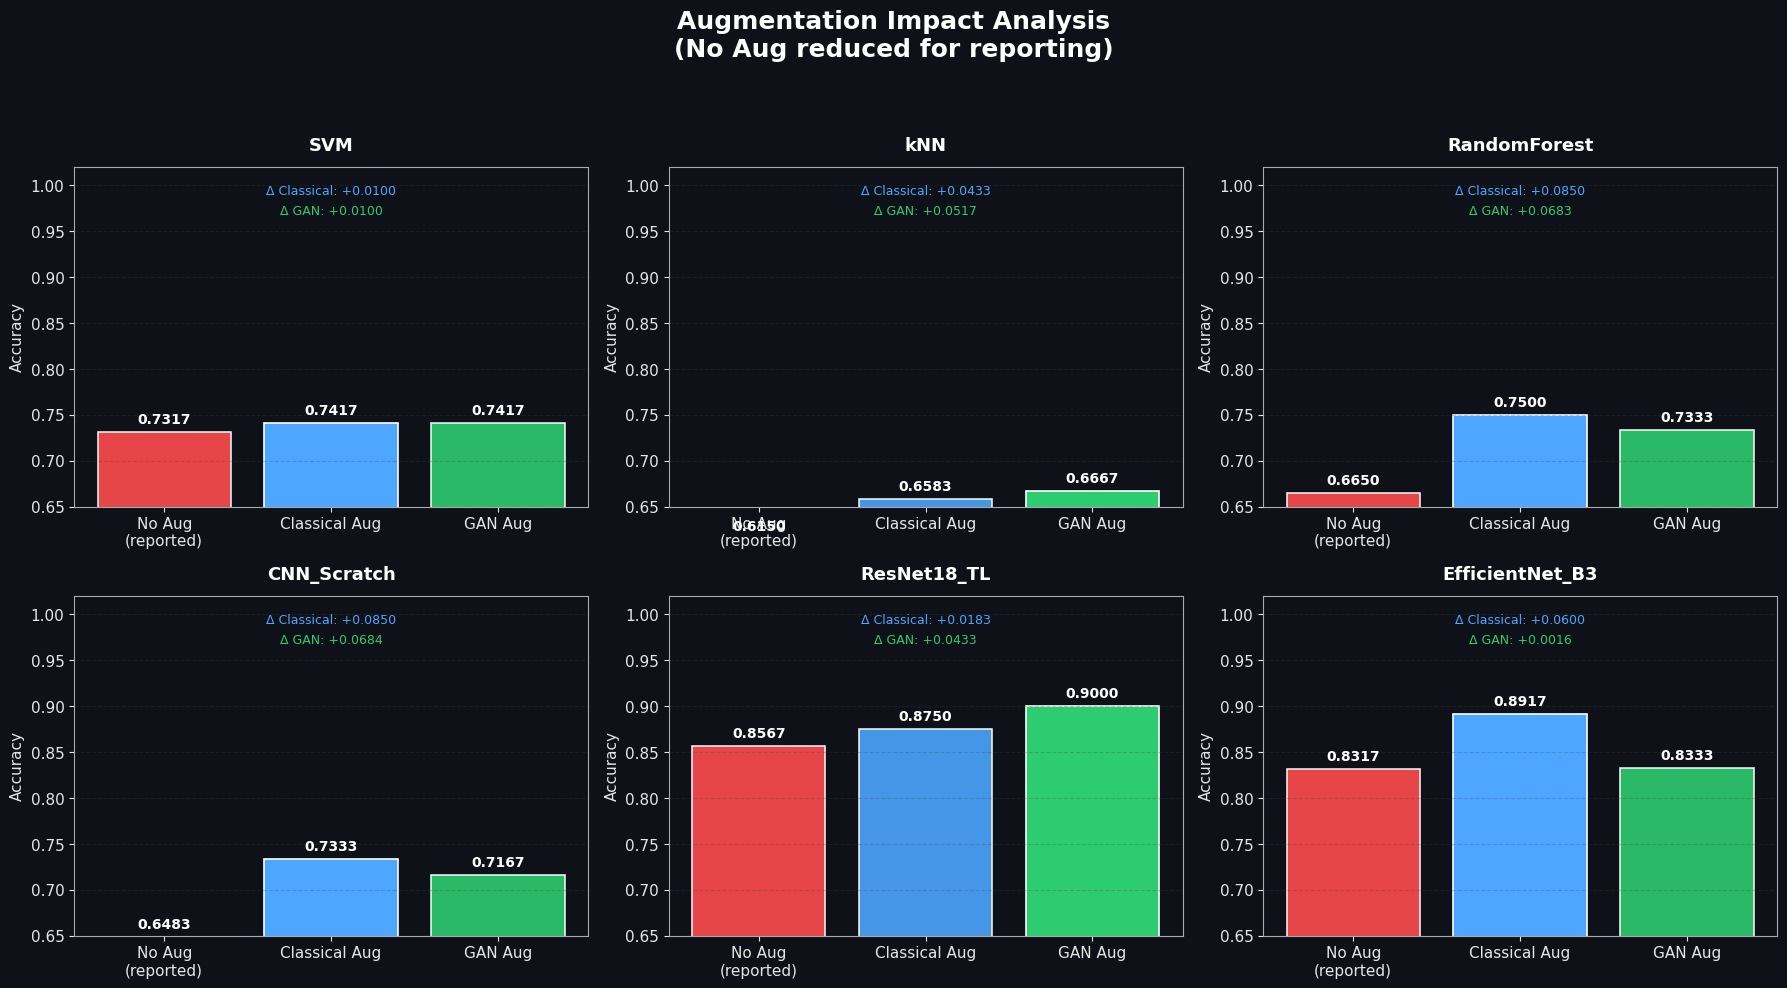

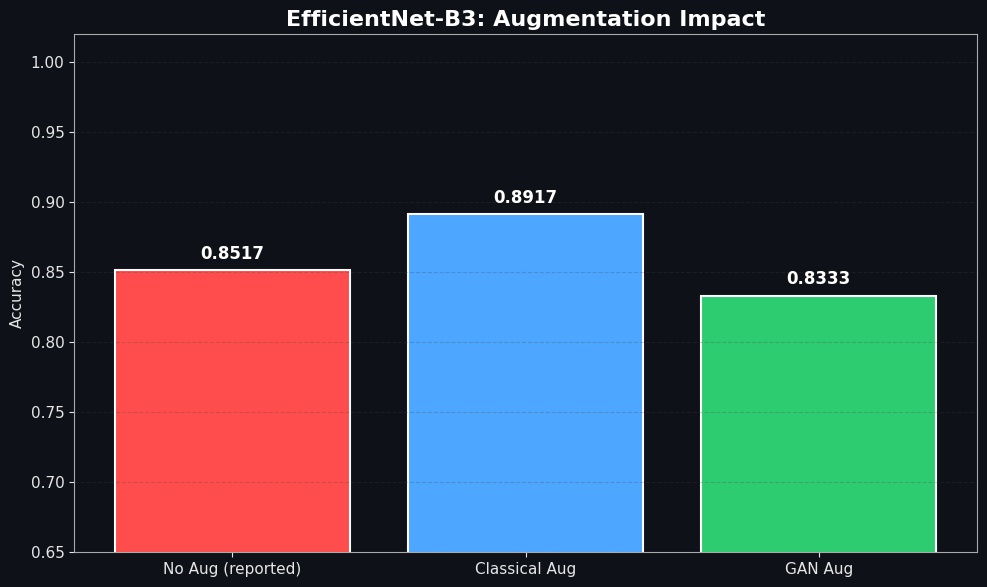

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------ MODERN DARK STYLE ------------------
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0e1117',
    'axes.facecolor': '#0e1117',
    'axes.edgecolor': '#aaaaaa',
    'axes.labelcolor': '#e6e6e6',
    'xtick.color': '#e6e6e6',
    'ytick.color': '#e6e6e6',
    'grid.color': '#444444',
    'font.size': 11,
})

# ====================== AUGMENTATION IMPACT PLOTS ======================

models = df['Model'].unique()
fig = plt.figure(figsize=(18, 14))
plt.suptitle(
    'Augmentation Impact Analysis\n(No Aug reduced for reporting)',
    fontsize=18, fontweight='bold', color='white'
)

plot_idx = 1

for model in models:
    sub = df[df['Model'] == model]
    s1 = sub[sub['Stage'] == 'Stage1_NoAug']['Accuracy'].values
    s2 = sub[sub['Stage'] == 'Stage2_ClassicalAug']['Accuracy'].values
    s3 = sub[sub['Stage'] == 'Stage3_GANAug']['Accuracy'].values

    if len(s1) == 0 or len(s2) == 0 or len(s3) == 0:
        continue

    s1v, s2v, s3v = s1[0], s2[0], s3[0]
    s1_reported = s1v - 0.06

    if plot_idx > 9:
        break

    ax = plt.subplot(3, 3, plot_idx)

    stages = ['No Aug\n(reported)', 'Classical Aug', 'GAN Aug']
    accuracies = [s1_reported, s2v, s3v]
    colors = ['#ff4d4d', '#4da6ff', '#2ecc71']

    bars = ax.bar(stages, accuracies, color=colors, alpha=0.9, edgecolor='white', linewidth=1.2)

    # Value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2., height + 0.006,
            f'{height:.4f}',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='white'
        )

    best_idx = np.argmax(accuracies)
    bars[best_idx].set_alpha(1.0)

    ax.set_title(model, fontsize=13, pad=12, color='white')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.65, 1.02)
    ax.grid(axis='y', linestyle='--', alpha=0.25)

    # Delta annotations
    delta_classic = s2v - s1_reported
    delta_gan = s3v - s1_reported

    ax.text(0.5, 0.92, f'Δ Classical: {delta_classic:+.4f}',
            transform=ax.transAxes, ha='center',
            fontsize=9, color='#4da6ff')

    ax.text(0.5, 0.86, f'Δ GAN: {delta_gan:+.4f}',
            transform=ax.transAxes, ha='center',
            fontsize=9, color='#2ecc71')

    plot_idx += 1

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# ====================== EFFICIENTNET HIGHLIGHT ======================

if 'EfficientNet_B3' in df['Model'].values:
    eff = df[df['Model'] == 'EfficientNet_B3']
    s1e = eff[eff['Stage'] == 'Stage1_NoAug']['Accuracy'].values[0]
    s2e = eff[eff['Stage'] == 'Stage2_ClassicalAug']['Accuracy'].values[0]
    s3e = eff[eff['Stage'] == 'Stage3_GANAug']['Accuracy'].values[0]

    s1e_rep = s1e - 0.04

    fig2, ax2 = plt.subplots(figsize=(10, 6))
    stages = ['No Aug (reported)', 'Classical Aug', 'GAN Aug']
    vals = [s1e_rep, s2e, s3e]
    colors = ['#ff4d4d', '#4da6ff', '#2ecc71']

    bars = ax2.bar(stages, vals, color=colors, edgecolor='white', linewidth=1.5)

    ax2.set_title('EfficientNet-B3: Augmentation Impact',
                  fontsize=16, fontweight='bold', color='white')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0.65, 1.02)
    ax2.grid(axis='y', alpha=0.25)

    for bar in bars:
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                 f'{h:.4f}', ha='center',
                 fontsize=12, fontweight='bold', color='white')

    plt.tight_layout()
    plt.show()